# Loading Kernal, Libraries and Dataframe

In [1]:
#Libraries
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Migrane.csv")
df.info

<bound method DataFrame.info of      Age  Duration  Frequency  Location  Character  Intensity  Nausea  Vomit  \
0     30         1          5         1          1          2       1      0   
1     50         3          5         1          1          3       1      1   
2     53         2          1         1          1          2       1      1   
3     45         3          5         1          1          3       1      0   
4     53         1          1         1          1          2       1      0   
..   ...       ...        ...       ...        ...        ...     ...    ...   
395   39         1          1         1          1          3       1      1   
396   20         3          2         1          1          3       1      0   
397   28         3          2         1          1          3       1      0   
398   20         3          1         1          1          3       1      0   
399   37         1          1         1          1          3       1      1   

     Ph

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          400 non-null    int64 
 1   Duration     400 non-null    int64 
 2   Frequency    400 non-null    int64 
 3   Location     400 non-null    int64 
 4   Character    400 non-null    int64 
 5   Intensity    400 non-null    int64 
 6   Nausea       400 non-null    int64 
 7   Vomit        400 non-null    int64 
 8   Phonophobia  400 non-null    int64 
 9   Photophobia  400 non-null    int64 
 10  Visual       400 non-null    int64 
 11  Sensory      400 non-null    int64 
 12  Dysphasia    400 non-null    int64 
 13  Dysarthria   400 non-null    int64 
 14  Vertigo      400 non-null    int64 
 15  Tinnitus     400 non-null    int64 
 16  Hypoacusis   400 non-null    int64 
 17  Diplopia     400 non-null    int64 
 18  Defect       400 non-null    int64 
 19  Ataxia       400 non-null    

In [4]:
df.head(3)

,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Vertigo,Tinnitus,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF,Type
0,30,1,5,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine
1,50,3,5,1,1,3,1,1,1,1,...,1,0,0,0,0,0,0,0,0,Typical aura with migraine
2,53,2,1,1,1,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,Typical aura with migraine


In [5]:
print(f"the number of null values is: \n{df.isnull().sum()}")


the number of null values is: 
Age            0
Duration       0
Frequency      0
Location       0
Character      0
Intensity      0
Nausea         0
Vomit          0
Phonophobia    0
Photophobia    0
Visual         0
Sensory        0
Dysphasia      0
Dysarthria     0
Vertigo        0
Tinnitus       0
Hypoacusis     0
Diplopia       0
Defect         0
Ataxia         0
Conscience     0
Paresthesia    0
DPF            0
Type           0
dtype: int64


# Step 1 Data Exploration

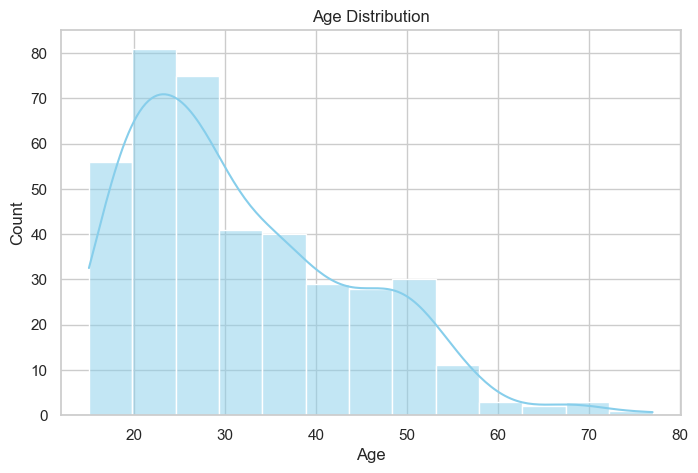

In [6]:

# Set visual style
sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

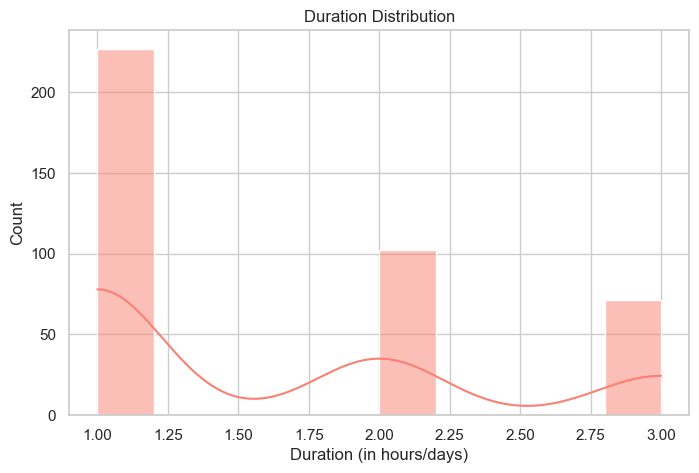

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Duration'], kde=True, color='salmon')
plt.title("Duration Distribution")
plt.xlabel("Duration (in hours/days)")
plt.ylabel("Count")
plt.show()

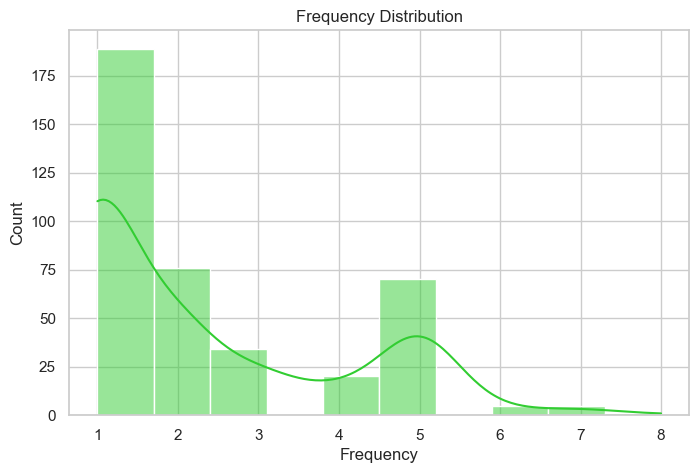

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Frequency'], kde=True, color='limegreen')
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")
plt.show()

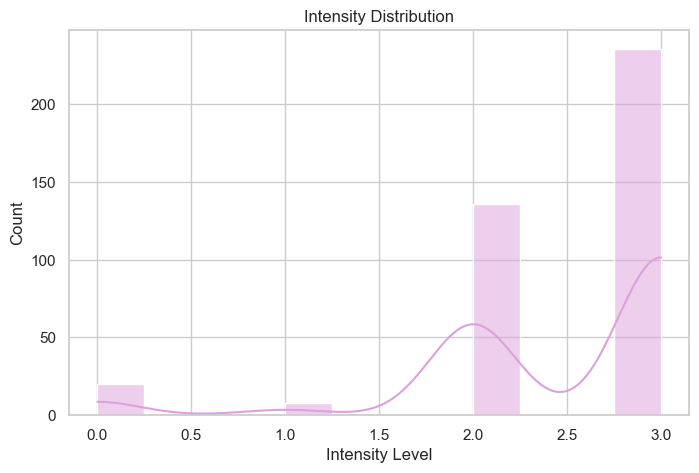

In [9]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Intensity'], kde=True, color='plum')
plt.title("Intensity Distribution")
plt.xlabel("Intensity Level")
plt.ylabel("Count")
plt.show()

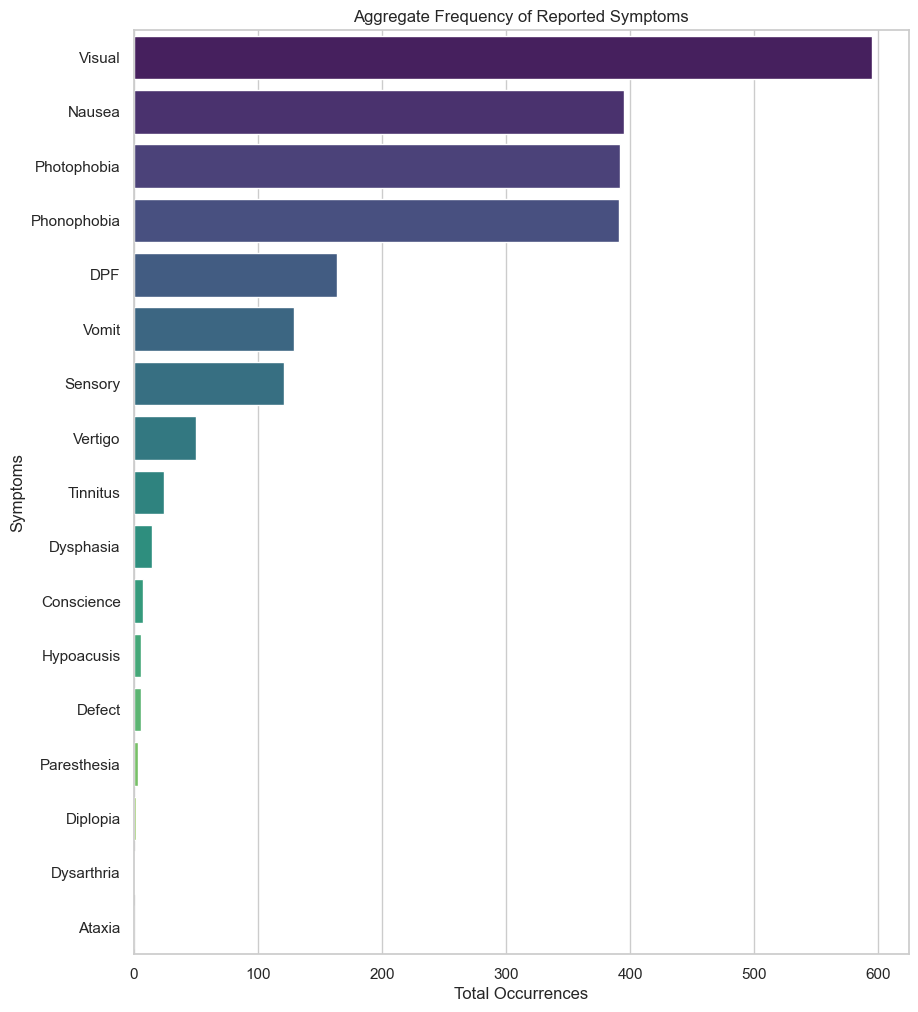

In [10]:
# Identify symptom columns
symptom_cols = df.columns[6:-1]
symptom_counts = df[symptom_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(x=symptom_counts.values, y=symptom_counts.index, palette="viridis")
plt.title("Aggregate Frequency of Reported Symptoms")
plt.xlabel("Total Occurrences")
plt.ylabel("Symptoms")
plt.show()

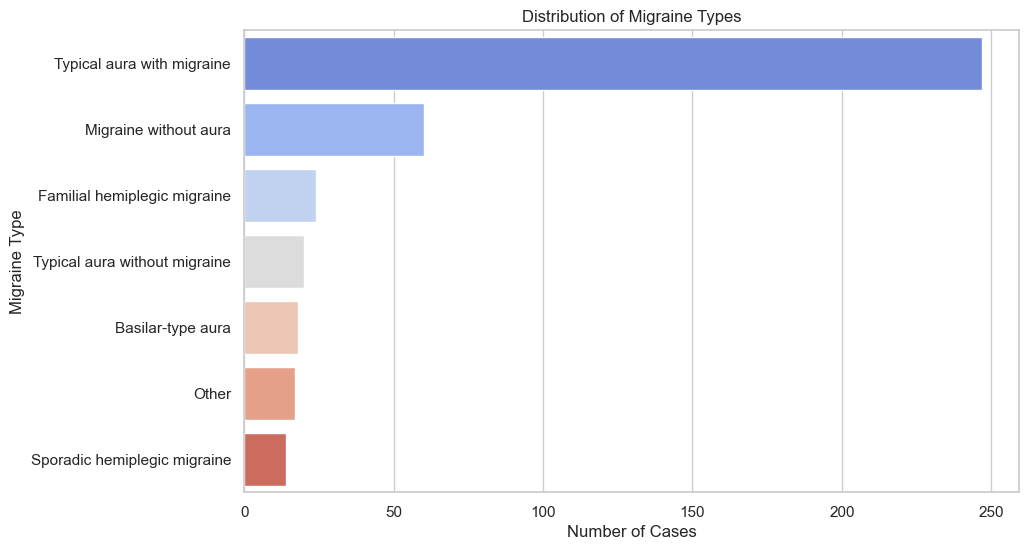

In [11]:
plt.figure(figsize=(10, 6))
type_counts = df['Type'].value_counts()

sns.barplot(x=type_counts.values, y=type_counts.index, palette='coolwarm')
plt.title("Distribution of Migraine Types")
plt.xlabel("Number of Cases")
plt.ylabel("Migraine Type")
plt.show()

<Figure size 1800x1600 with 0 Axes>

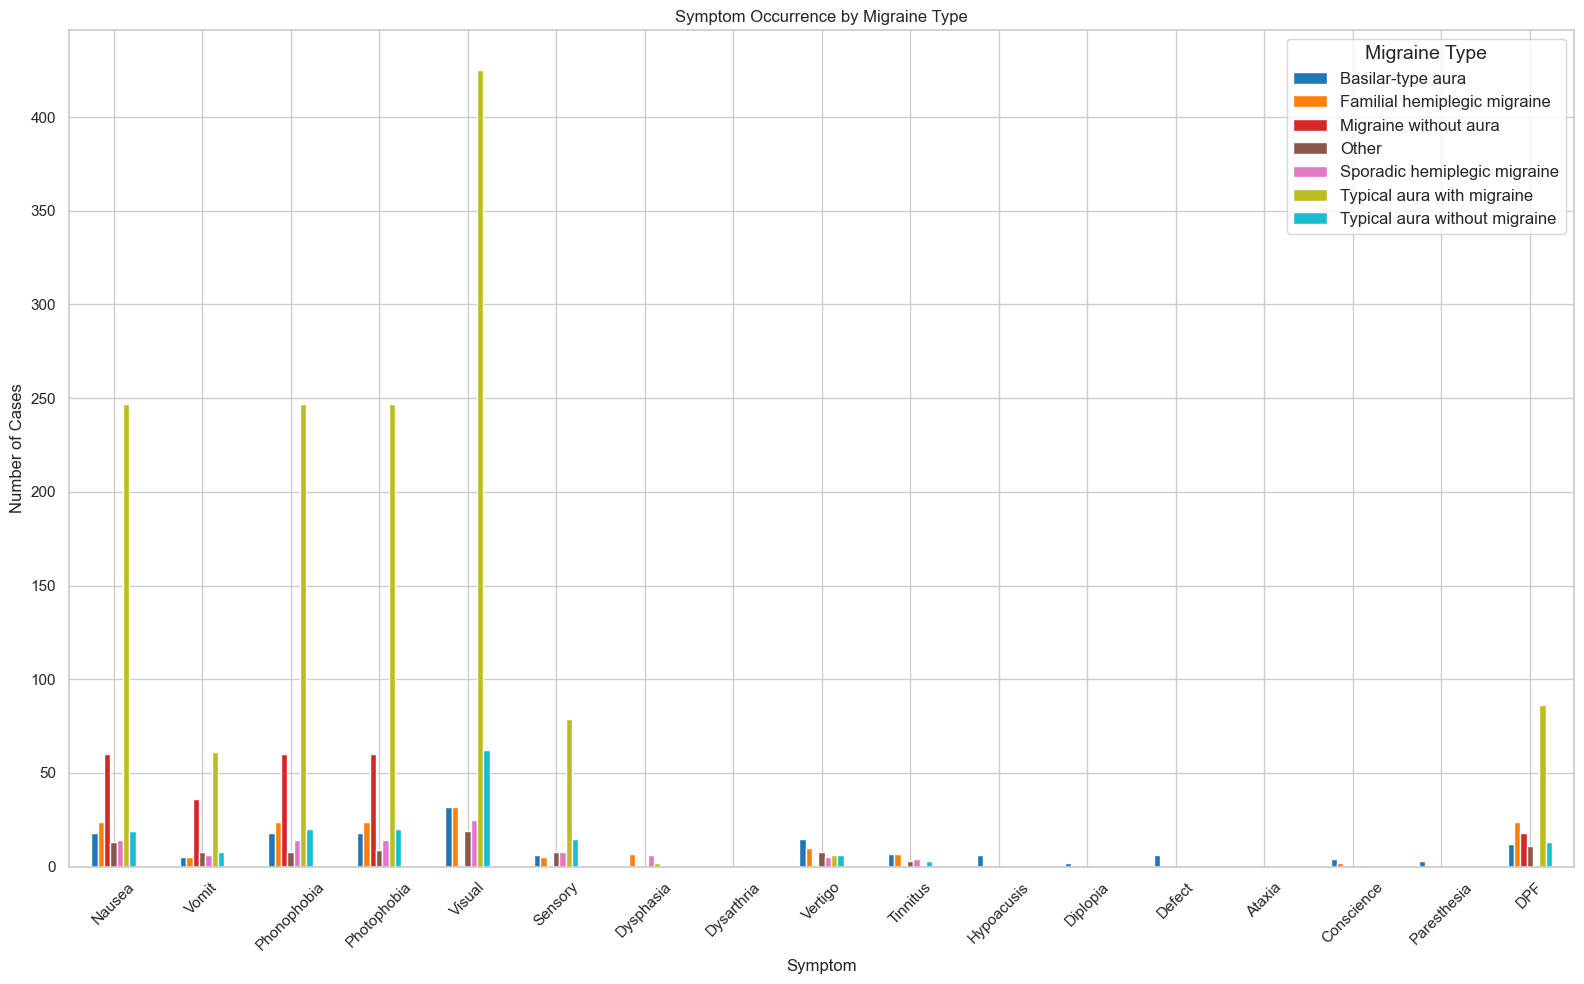

In [12]:

# Identify symptom columns and migraine types
symptom_cols = df.columns[6:-1]
migraine_types = df['Type'].unique()

# Aggregate symptoms by migraine type
symptom_by_type = df.groupby('Type')[symptom_cols].sum().T

# Normalize counts (optional: for proportions)
# symptom_by_type = symptom_by_type.div(symptom_by_type.sum(axis=0), axis=1)

# Plot grouped bar chart
plt.figure(figsize=(18, 16))
symptom_by_type.plot(kind='bar', figsize=(16, 10), colormap='tab10')

plt.title("Symptom Occurrence by Migraine Type")
plt.ylabel("Number of Cases")
plt.xlabel("Symptom")
plt.xticks(rotation=45)
plt.legend(title="Migraine Type", fontsize=12, title_fontsize=14, loc='upper right')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Proportion')

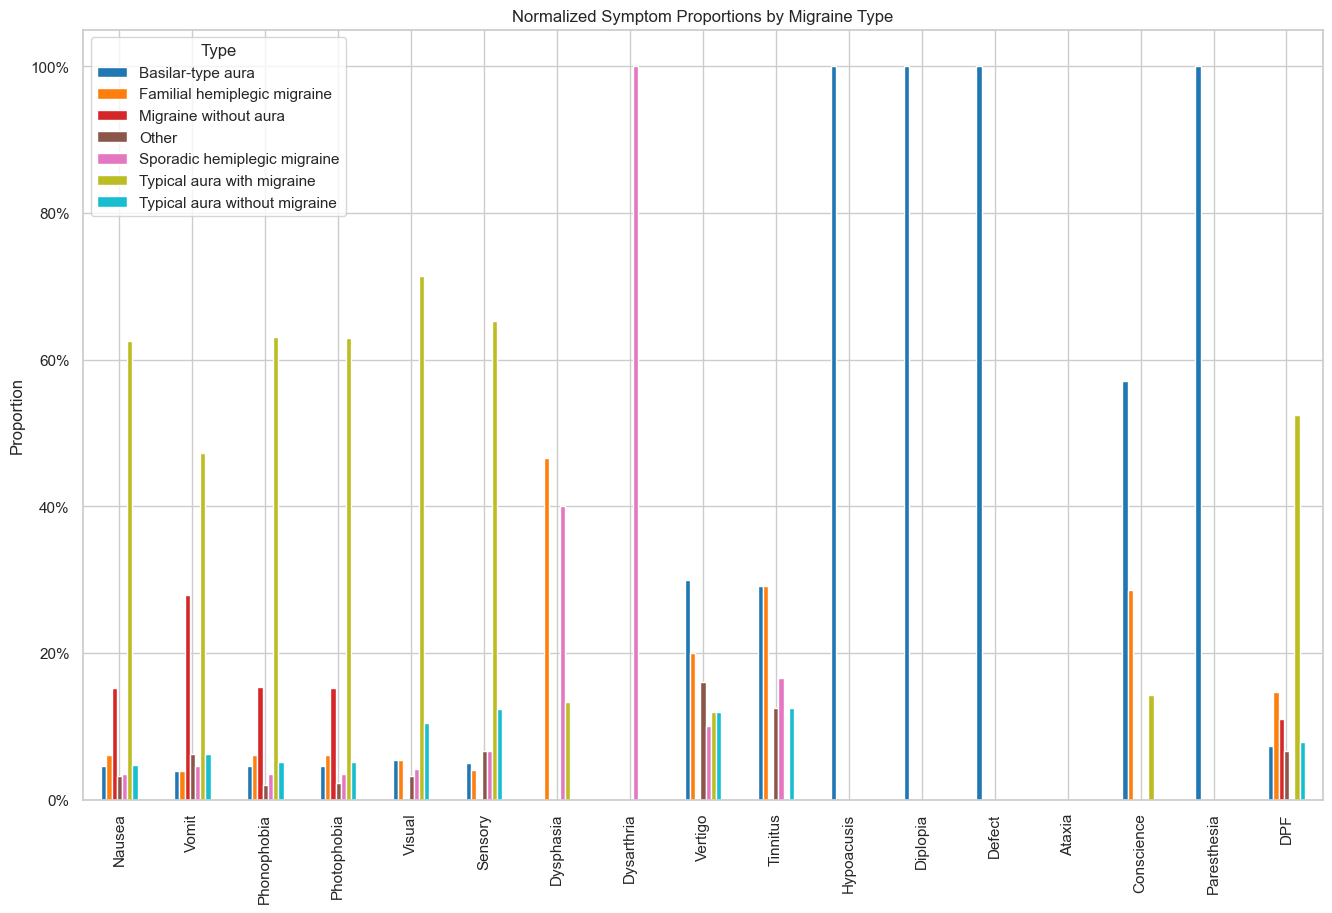

In [13]:
symptom_by_type_norm = symptom_by_type.div(symptom_by_type.sum(axis=1), axis=0)

symptom_by_type_norm.plot(kind='bar', figsize=(16, 10), colormap='tab10')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.title("Normalized Symptom Proportions by Migraine Type")
plt.ylabel("Proportion")

Text(0, 0.5, 'Proportion')

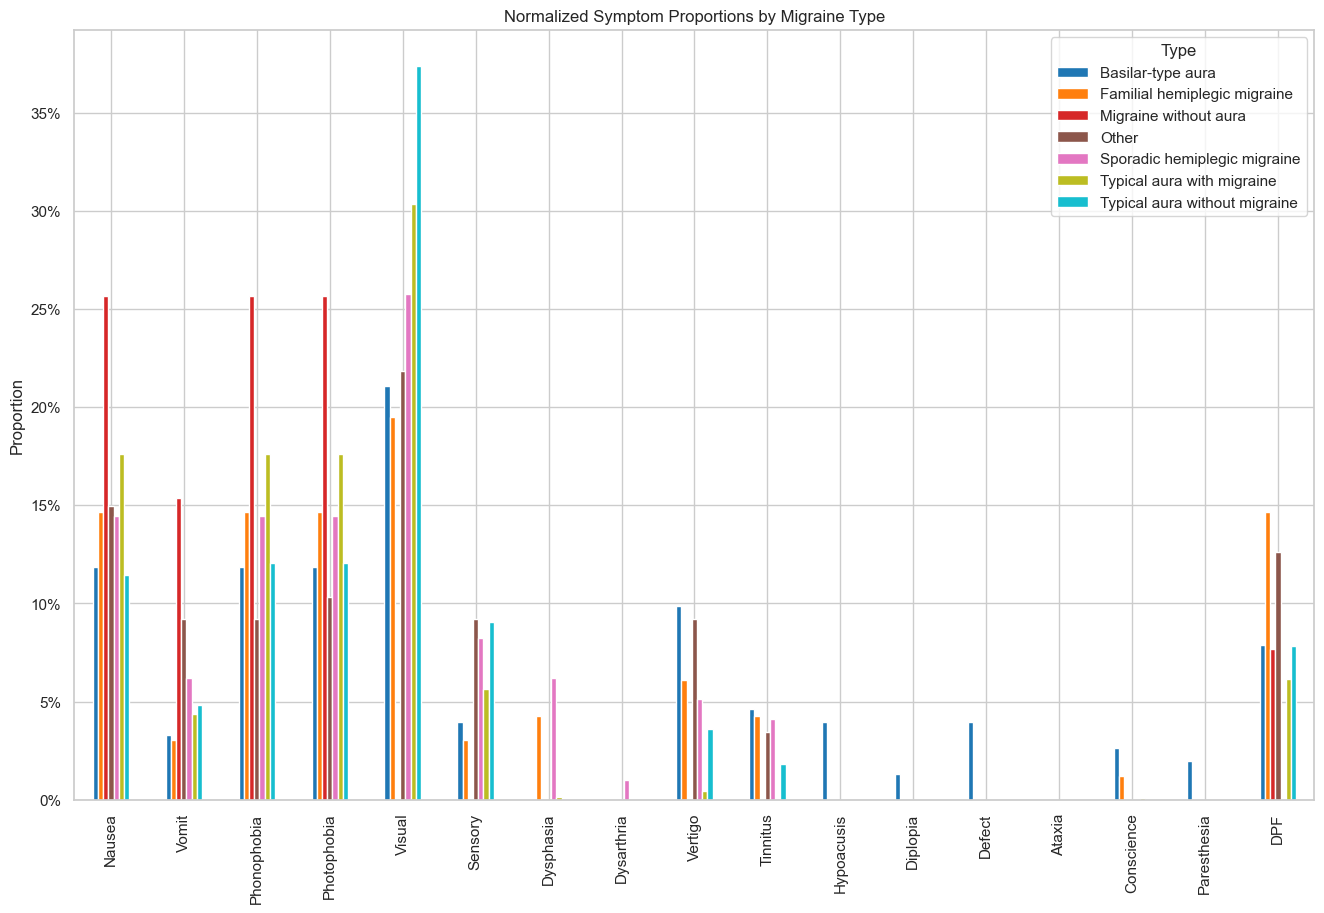

In [14]:
symptom_by_type_norm = symptom_by_type.div(symptom_by_type.sum(axis=0), axis=1)

symptom_by_type_norm.plot(kind='bar', figsize=(16, 10), colormap='tab10')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.title("Normalized Symptom Proportions by Migraine Type")
plt.ylabel("Proportion")

In [15]:
df.corr(numeric_only = True)

,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Dysarthria,Vertigo,Tinnitus,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF
Age,1.000000,-0.045263,0.073431,0.133766,0.128077,0.114036,0.006542,-0.028650,-0.101022,-0.031461,...,-0.048333,-0.026967,-0.098046,-0.008872,0.033883,0.028449,NaN,-0.039212,-0.000275,0.088623
Duration,-0.045263,1.000000,0.149240,-0.003515,0.005733,0.052115,-0.144654,-0.046468,-0.011165,-0.072356,...,-0.039660,0.122716,-0.022421,0.009082,0.035904,0.062503,NaN,-0.056207,0.081661,0.072351
Frequency,0.073431,0.149240,1.000000,-0.033373,-0.030762,0.070793,0.037977,0.133929,0.043154,0.031151,...,-0.010917,-0.064355,-0.061381,-0.063772,-0.057808,-0.076059,NaN,-0.097445,-0.053578,0.052049
Location,0.133766,-0.003515,-0.033373,1.000000,0.933517,0.658737,-0.011551,0.030900,-0.267320,-0.214672,...,0.005140,-0.045861,-0.013362,0.012670,0.007278,0.012670,NaN,0.013702,0.008925,-0.028276
Character,0.128077,0.005733,-0.030762,0.933517,1.000000,0.648325,-0.009123,0.017396,-0.437568,-0.397716,...,0.004059,-0.023838,-0.017451,0.010007,0.005748,0.010007,NaN,0.010822,0.007049,-0.023997
Intensity,0.114036,0.052115,0.070793,0.658737,0.648325,1.000000,0.010261,-0.011358,-0.104765,-0.098647,...,-0.030656,-0.024622,-0.099848,0.031620,0.048950,0.085214,NaN,0.092158,0.060027,-0.073378
Nausea,0.006542,-0.144654,0.037977,-0.011551,-0.009123,0.010261,1.000000,0.077624,0.134659,0.466108,...,0.005632,-0.161592,-0.066325,0.013884,0.007976,0.013884,NaN,0.015015,0.009780,-0.134965
Vomit,-0.028650,-0.046468,0.133929,0.030900,0.017396,-0.011358,0.077624,1.000000,-0.003516,0.022157,...,0.072561,-0.082881,-0.039186,-0.041140,0.026919,0.002860,NaN,0.030285,0.002015,0.022945
Phonophobia,-0.101022,-0.011165,0.043154,-0.267320,-0.437568,-0.104765,0.134659,-0.003516,1.000000,0.700786,...,0.007595,-0.197516,0.038331,0.018722,0.010755,0.018722,NaN,0.020248,0.013189,-0.044900
Photophobia,-0.031461,-0.072356,0.031151,-0.214672,-0.397716,-0.098647,0.466108,0.022157,0.700786,1.000000,...,0.007152,-0.161985,0.036092,0.017629,0.010127,0.017629,NaN,0.019066,0.012418,-0.062449


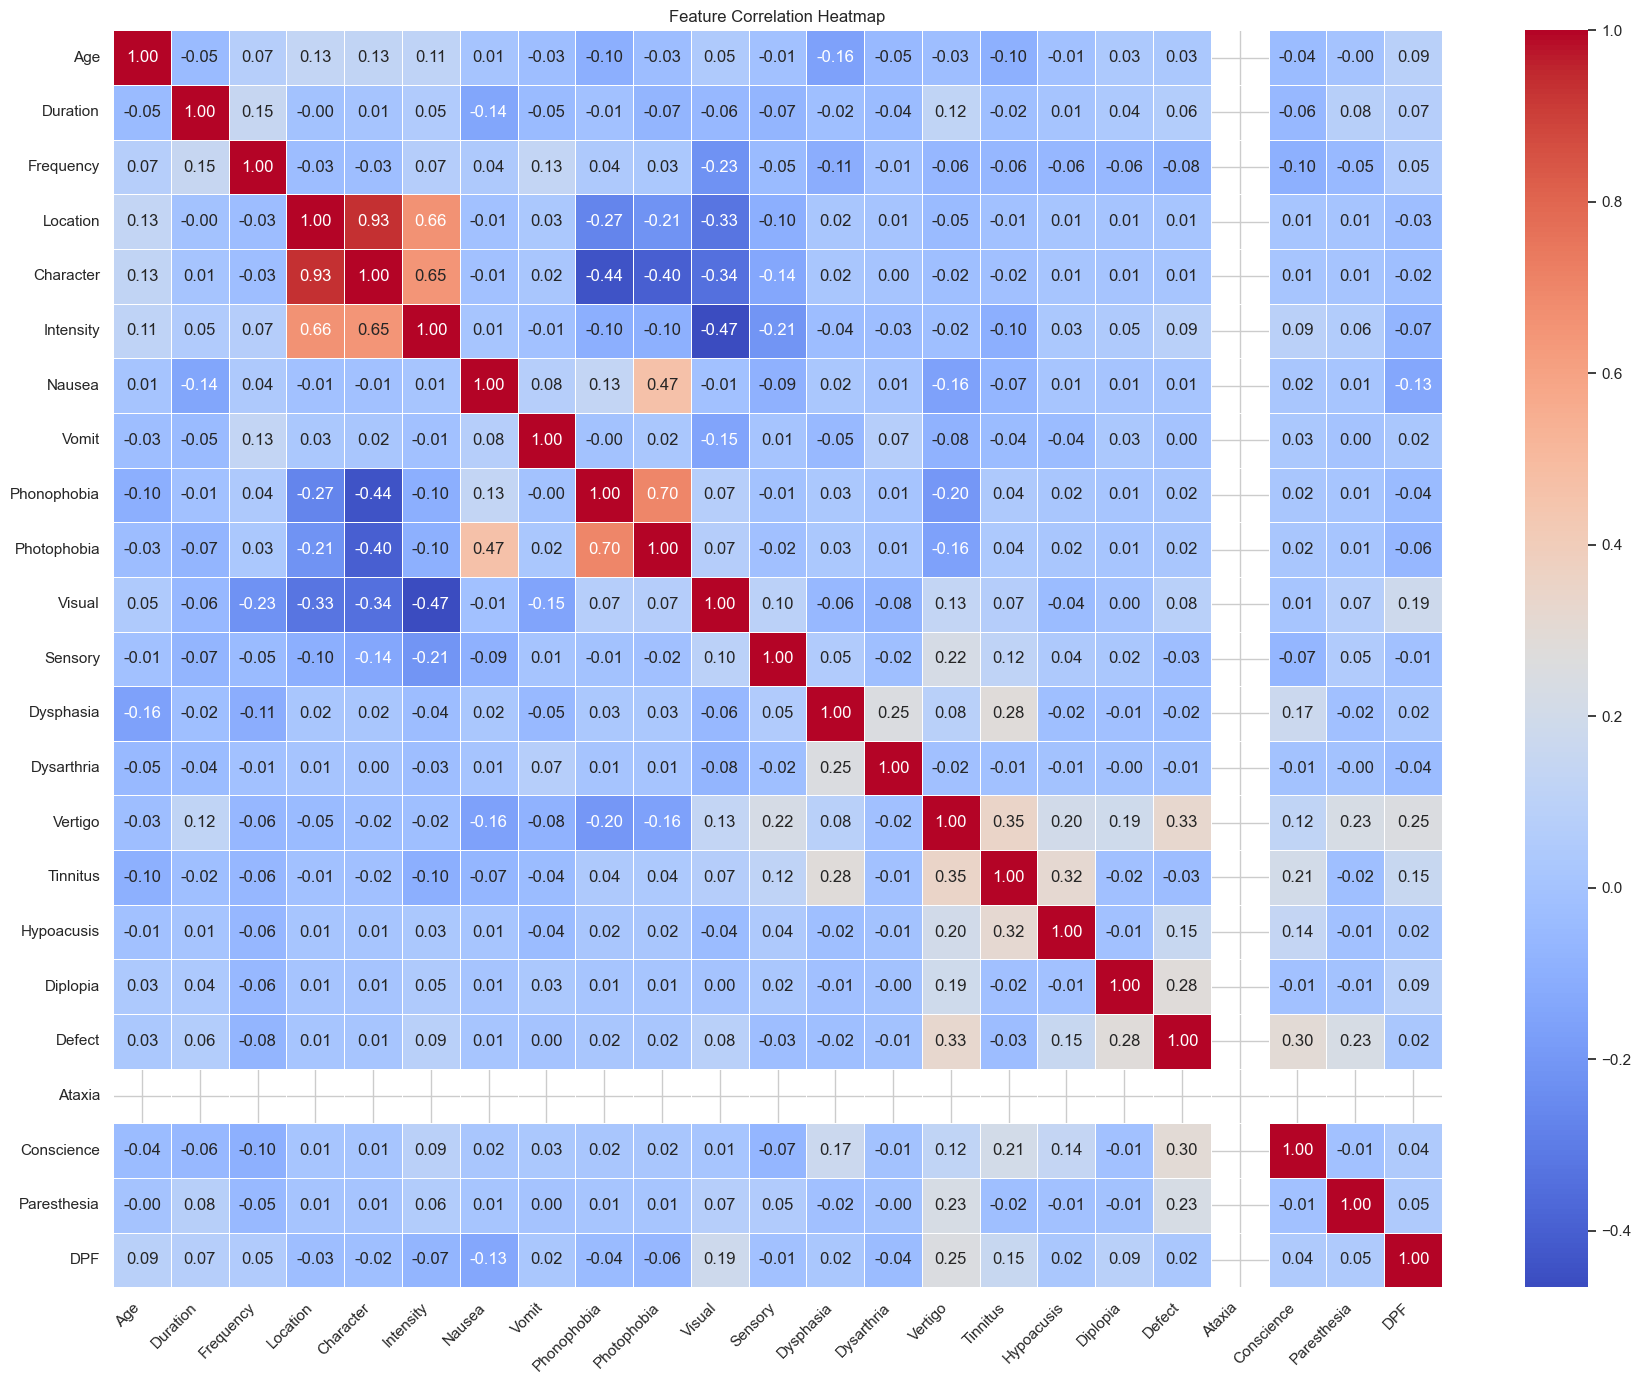

In [16]:
corr_matrix = df.drop(columns=['Type']).corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Heatmap shows high correlation between Photophobia and Phonophobia as well as high correlation between Sensory and Visual
a lesser mild correlation is also present between Frequenct and intensity

Scatterplots will better show the correlation

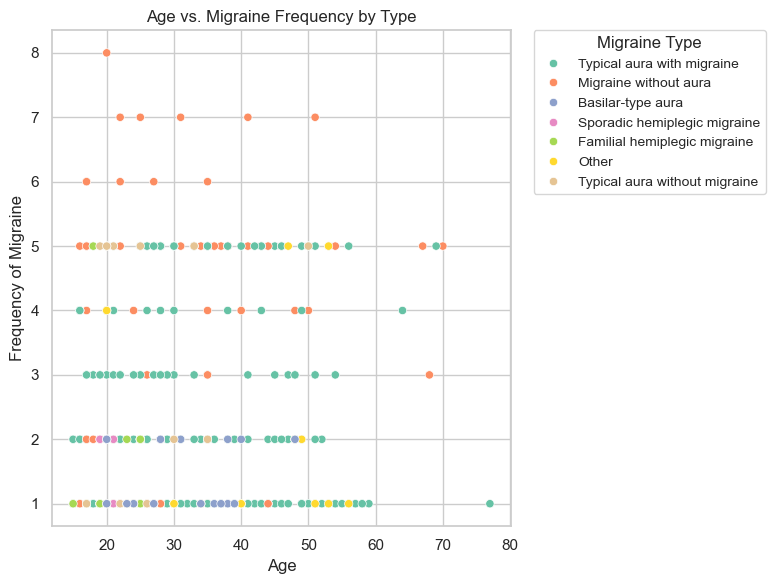

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Frequency', hue='Type', data=df, palette='Set2')
plt.title("Age vs. Migraine Frequency by Type")
plt.xlabel("Age")
plt.ylabel("Frequency of Migraine")
# Shift legend outside the plot
plt.legend(title="Migraine Type", fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()


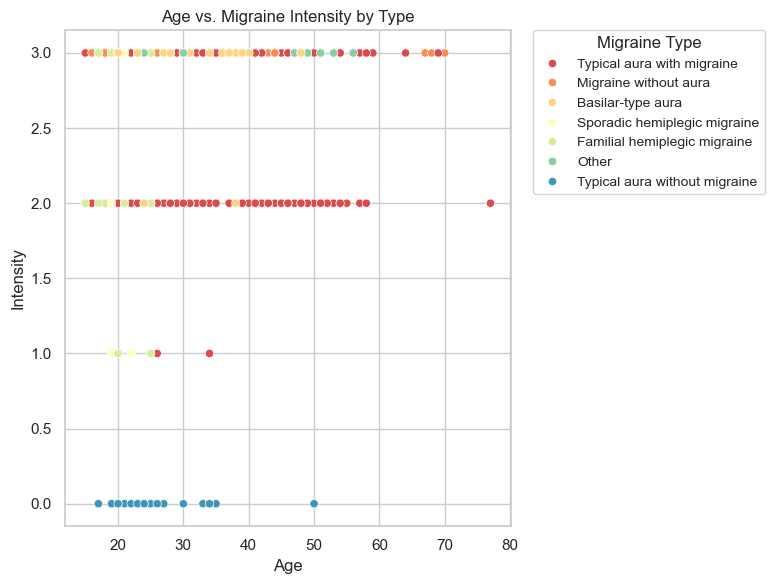

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Intensity', hue='Type', data=df, palette='Spectral')
plt.title("Age vs. Migraine Intensity by Type")
plt.xlabel("Age")
plt.ylabel("Intensity")
# Shift legend outside the plot
plt.legend(title="Migraine Type", fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()


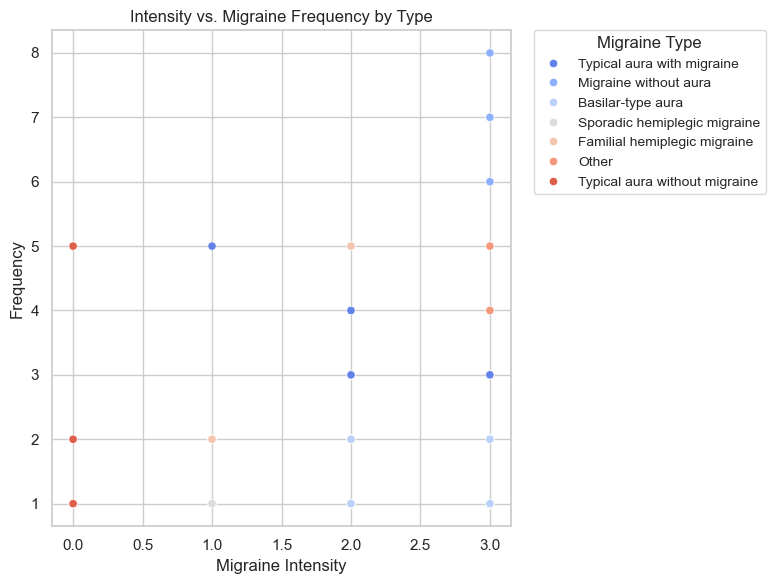

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Intensity', y='Frequency', hue='Type', data=df, palette='coolwarm')

plt.title("Intensity vs. Migraine Frequency by Type")
plt.xlabel("Migraine Intensity")
plt.ylabel("Frequency")

# Shift legend outside the plot
plt.legend(title="Migraine Type", fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()


In [20]:
from sklearn.preprocessing import StandardScaler


# Select numeric columns excluding binary symptoms
numeric_cols = ['Age', 'Duration', 'Frequency', 'Intensity']
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Set style
sns.set(style="whitegrid")


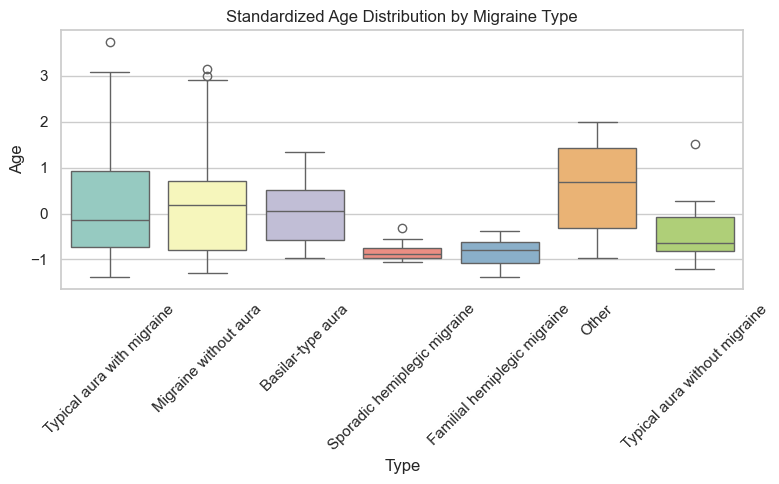

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Type', y='Age', data=df_scaled, palette='Set3')
plt.title("Standardized Age Distribution by Migraine Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


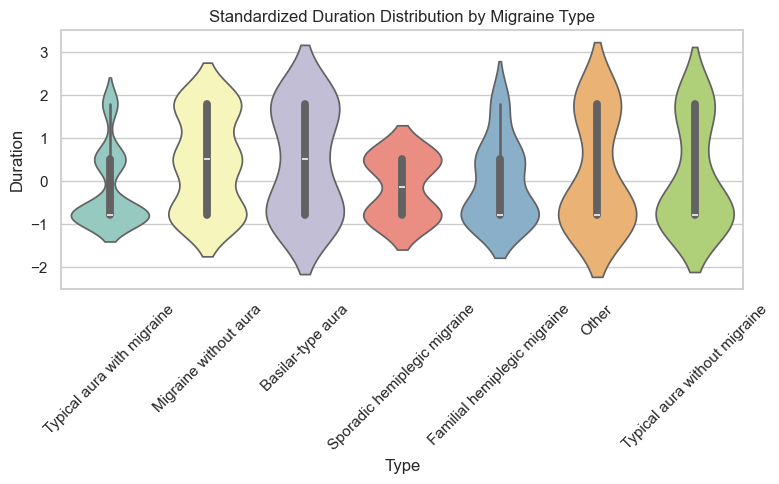

In [22]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Type', y='Duration', data=df_scaled, palette='Set3')
plt.title("Standardized Duration Distribution by Migraine Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


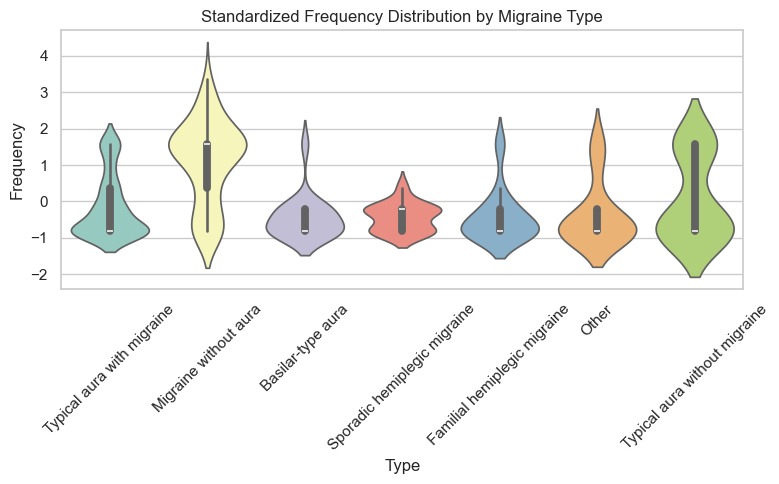

In [23]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Type', y='Frequency', data=df_scaled, palette='Set3')
plt.title("Standardized Frequency Distribution by Migraine Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


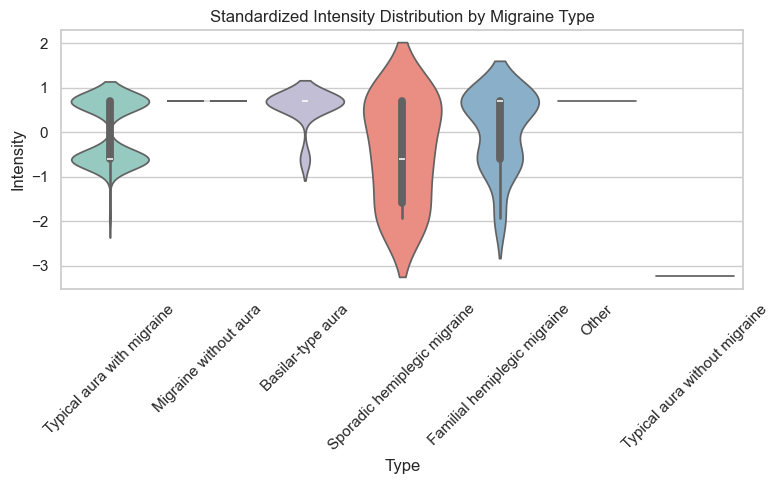

In [24]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Type', y='Intensity', data=df_scaled, palette='Set3')
plt.title("Standardized Intensity Distribution by Migraine Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


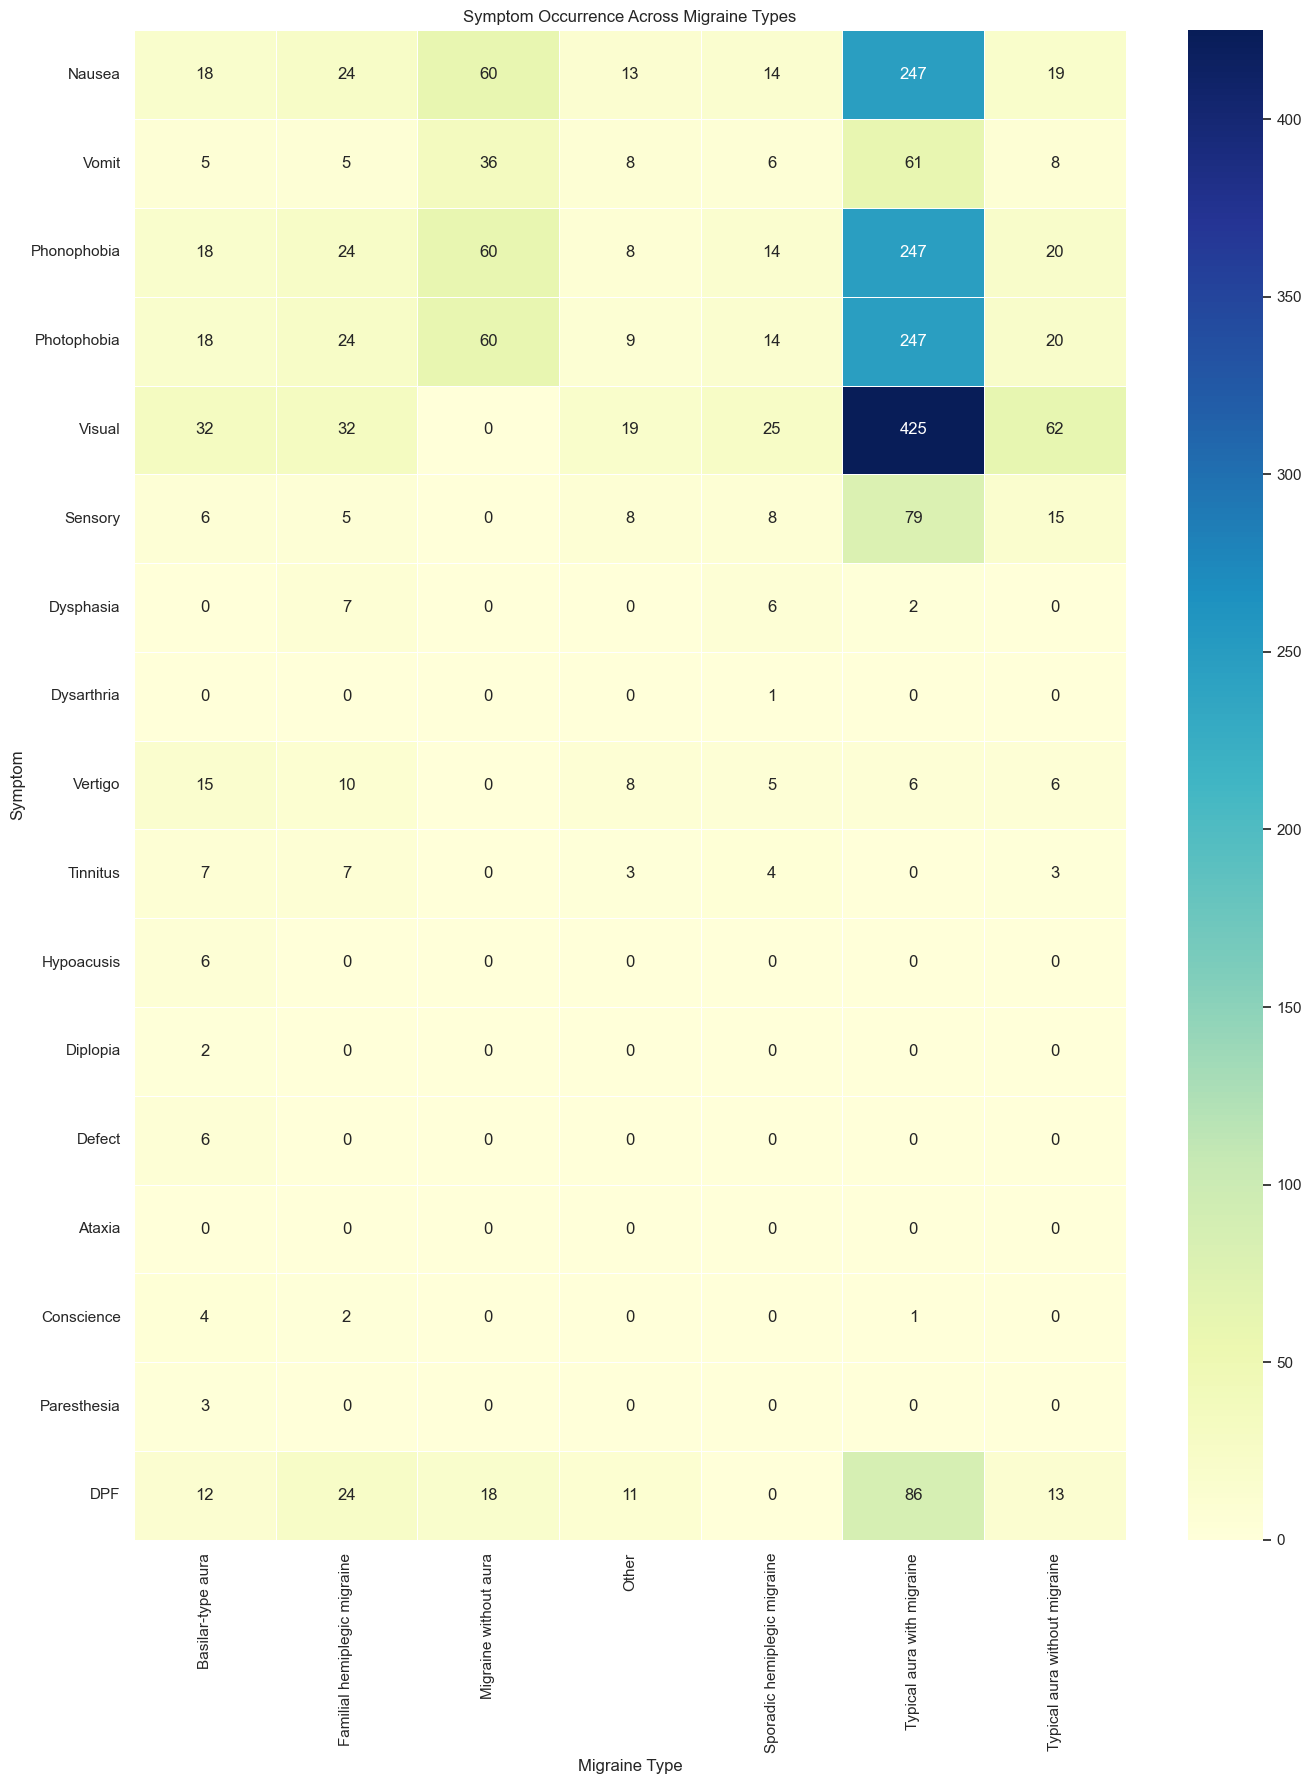

In [25]:
# Identify symptom columns (excluding non-symptoms)
symptom_cols = df.columns[6:-1]

# Compute total symptom counts per type
symptom_heat = df.groupby('Type')[symptom_cols].sum().T

# Plot heatmap
plt.figure(figsize=(14, 18))
sns.heatmap(symptom_heat, annot=True, fmt="d", cmap="YlGnBu", linewidths=0.5)

plt.title("Symptom Occurrence Across Migraine Types")
plt.xlabel("Migraine Type")
plt.ylabel("Symptom")
plt.tight_layout()
plt.show()

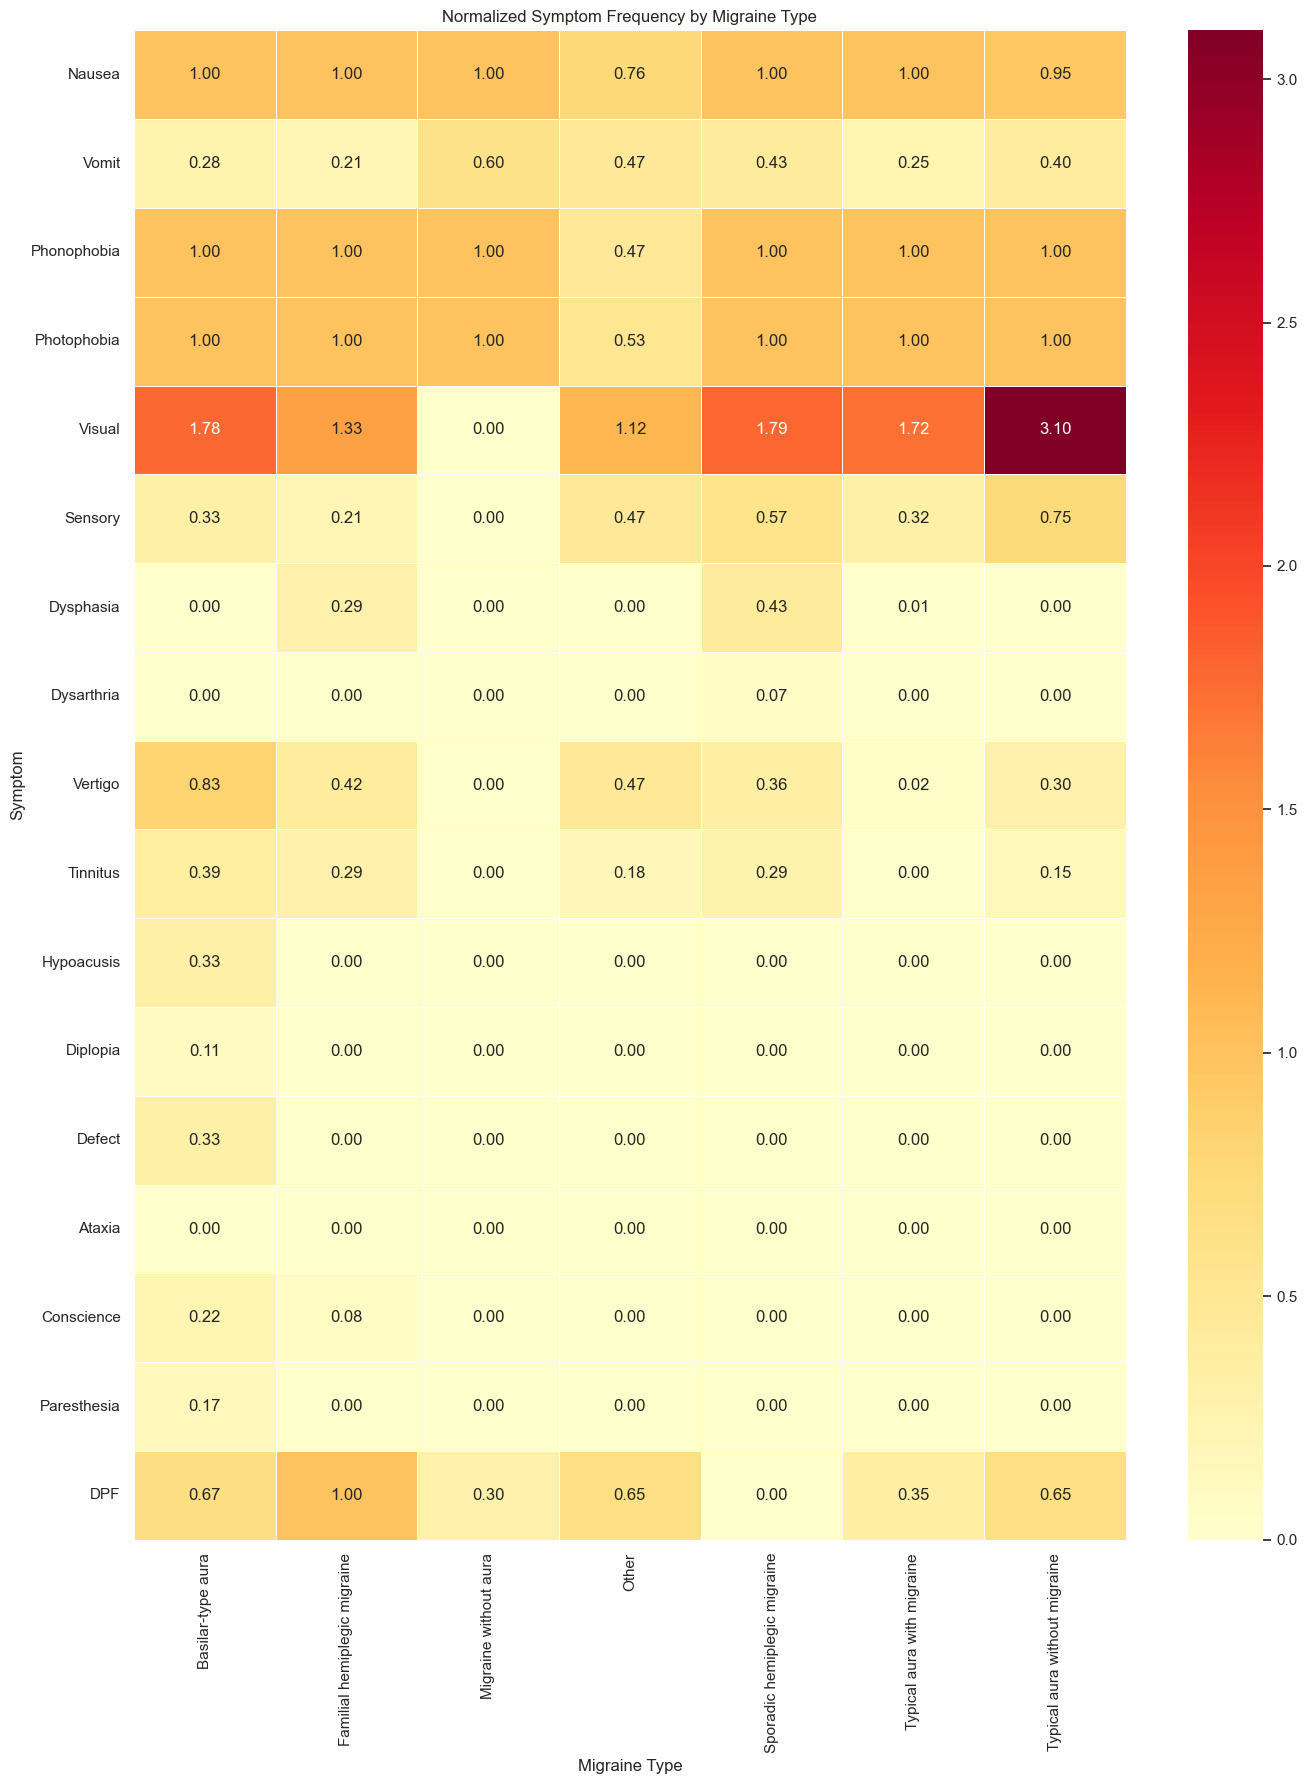

In [26]:
# Identify symptom columns
symptom_cols = df.columns[6:-1]

# Calculate normalized symptom frequency
type_counts = df['Type'].value_counts()
normalized_heat = df.groupby('Type')[symptom_cols].sum().T
normalized_heat = normalized_heat.divide(type_counts, axis=1)

# Plot heatmap
plt.figure(figsize=(14, 18))
sns.heatmap(normalized_heat, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)

plt.title("Normalized Symptom Frequency by Migraine Type")
plt.xlabel("Migraine Type")
plt.ylabel("Symptom")
plt.tight_layout()
plt.show()

# Step 2 Data Preprocessing

In [27]:
#I'm spescifically told to encode theses columns even though they are already encoded....

from sklearn.preprocessing import LabelEncoder

# Make a copy of the original DataFrame
df_encoded = df.copy()

# Initialize label encoders
location_encoder = LabelEncoder()
character_encoder = LabelEncoder()

# Apply label encoding
df_encoded['Location_encoded'] = location_encoder.fit_transform(df_encoded['Location'])
df_encoded['Character_encoded'] = character_encoder.fit_transform(df_encoded['Character'])

# Preview the result
df_encoded[['Location', 'Location_encoded', 'Character', 'Character_encoded']].head()

,Location,Location_encoded,Character,Character_encoded
0,1,1,1,1
1,1,1,1,1
2,1,1,1,1
3,1,1,1,1
4,1,1,1,1


In [28]:
df_encoded.head()

,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF,Type,Location_encoded,Character_encoded
0,30,1,5,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
1,50,3,5,1,1,3,1,1,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
2,53,2,1,1,1,2,1,1,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
3,45,3,5,1,1,3,1,0,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
4,53,1,1,1,1,2,1,0,1,1,...,0,0,0,0,0,0,1,Typical aura with migraine,1,1


In [29]:
from sklearn.preprocessing import MultiLabelBinarizer

symptom_data = [
    ['headache', 'nausea', 'visual'],
    ['nausea', 'motor', 'unilateral']


    
]

# Initialize and fit
mlb = MultiLabelBinarizer()
X_symptoms = mlb.fit_transform(symptom_data)

# Save for reuse
import joblib
joblib.dump(mlb, 'mlb.pkl')

joblib.dump(list(mlb.classes_), 'training_feature_names.pkl')  # Optional feature order



['training_feature_names.pkl']

In [30]:


# Features to scale
scale_cols = ['Age', 'Duration', 'Frequency']

# Initialize scaler
scaler = StandardScaler()

# Apply transformation
df_scaled = df_encoded.copy()
df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

# Preview scaled values
df_scaled[scale_cols].head()

,Age,Duration,Frequency
0,-0.140632,-0.792208,1.574215
1,1.509008,1.805195,1.574215
2,1.756454,0.506494,-0.815485
3,1.096598,1.805195,1.574215
4,1.756454,-0.792208,-0.815485


In [31]:
df_scaled.head()

,Age,Duration,Frequency,Location,Character,Intensity,Nausea,Vomit,Phonophobia,Photophobia,...,Hypoacusis,Diplopia,Defect,Ataxia,Conscience,Paresthesia,DPF,Type,Location_encoded,Character_encoded
0,-0.140632,-0.792208,1.574215,1,1,2,1,0,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
1,1.509008,1.805195,1.574215,1,1,3,1,1,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
2,1.756454,0.506494,-0.815485,1,1,2,1,1,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
3,1.096598,1.805195,1.574215,1,1,3,1,0,1,1,...,0,0,0,0,0,0,0,Typical aura with migraine,1,1
4,1.756454,-0.792208,-0.815485,1,1,2,1,0,1,1,...,0,0,0,0,0,0,1,Typical aura with migraine,1,1


In [32]:

from imblearn.over_sampling import SMOTE


# Encode target variable
df_smote = df_scaled.copy() # df_scaled is also encoded
df_smote['Type_encoded'] = LabelEncoder().fit_transform(df_smote['Type'])

# Prepare features — exclude raw 'Type' and any non-numeric columns
exclude_cols = ['Type', 'Type_encoded', 'Location', 'Character']
X = df_smote.drop(columns=exclude_cols)

# If Location and Character are informative, encode them numerically
X['Location_encoded'] = LabelEncoder().fit_transform(df['Location'])
X['Character_encoded'] = LabelEncoder().fit_transform(df['Character'])

# Final feature set and target
y = df_smote['Type_encoded']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Check balance
print("Balanced class distribution:", Counter(y_resampled))

Balanced class distribution: Counter({5: 247, 2: 247, 0: 247, 4: 247, 1: 247, 3: 247, 6: 247})


### Feature selction / Dimensional reduction

In [33]:

model = RandomForestClassifier()
model.fit(X_resampled, y_resampled)
importances = model.feature_importances_

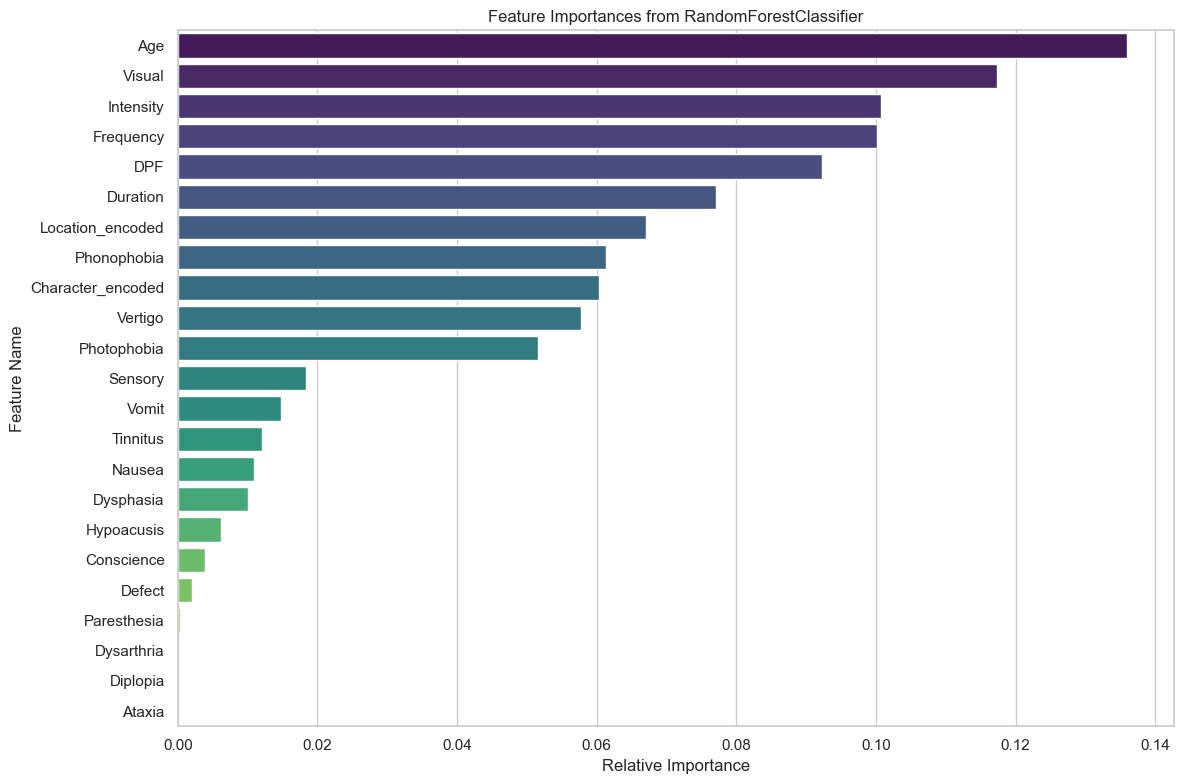

In [34]:
feature_names = X_resampled.columns
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances_df, palette='viridis')
plt.title("Feature Importances from RandomForestClassifier")
plt.xlabel("Relative Importance")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()


In [35]:
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_resampled, y_resampled)


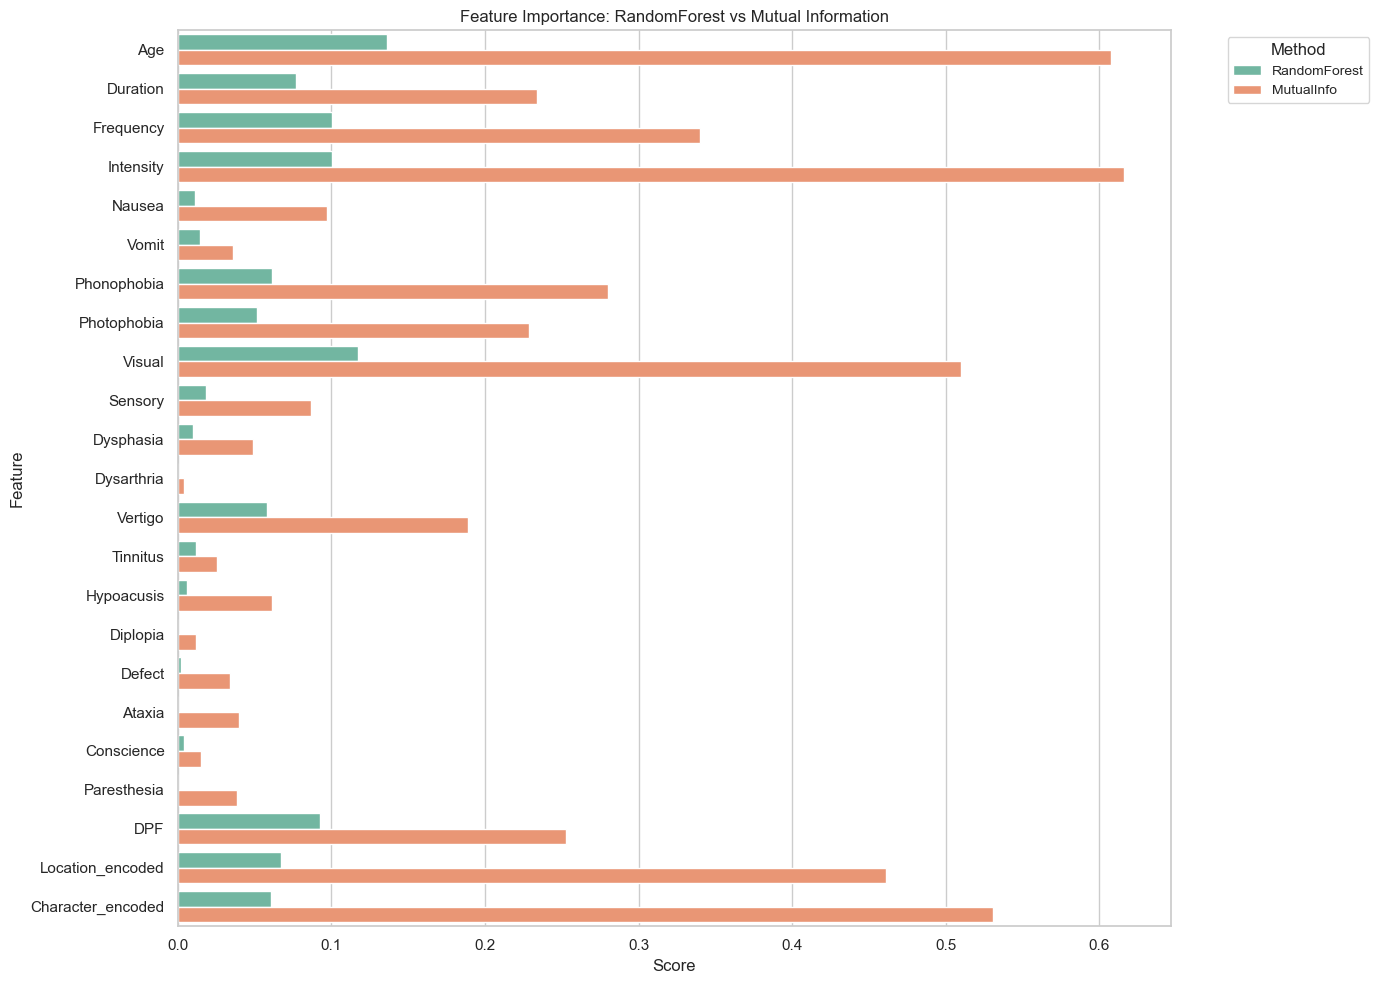

In [36]:

# Reuse feature names
feature_names = X_resampled.columns

# Create DataFrame for comparison
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RandomForest': model.feature_importances_,
    'MutualInfo': mi_scores
})

# Melt for grouped barplot
compare_df = importance_df.melt(id_vars='Feature', var_name='ScoreType', value_name='Score')

# Plot side-by-side bars
plt.figure(figsize=(14, 10))
sns.barplot(x='Score', y='Feature', hue='ScoreType', data=compare_df, palette='Set2')

plt.title("Feature Importance: RandomForest vs Mutual Information")
plt.xlabel("Score")
plt.ylabel("Feature")
plt.legend(title="Method", fontsize=10, title_fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=10)
X_selected = selector.fit_transform(X_resampled, y_resampled)


In [38]:

# Step 1: Create a DataFrame of mutual info scores
mi_df = pd.DataFrame({
    'Feature': X_resampled.columns,
    'MutualInfo': mi_scores
})

# Step 2: Identify selected features from SelectKBest
selected_mask = selector.get_support()  # Boolean mask of selected features
mi_df['SelectedByKBest'] = selected_mask.astype(int)  # 1 if selected, 0 otherwise

# Step 3: Create a combined ranking score (optional)
# For example, score = MI rank + selection boost
mi_df['CombinedScore'] = mi_df['MutualInfo'] + mi_df['SelectedByKBest'] * mi_df['MutualInfo'].max()

# Step 4: Sort by combined score
mi_df = mi_df.sort_values(by='CombinedScore', ascending=False)

# View top-ranked features
mi_df.head(10)

,Feature,MutualInfo,SelectedByKBest,CombinedScore
3,Intensity,0.615960,1,1.231921
0,Age,0.607798,1,1.223758
22,Character_encoded,0.530957,1,1.146918
8,Visual,0.509738,1,1.125699
21,Location_encoded,0.461009,1,1.076969
2,Frequency,0.340240,1,0.956200
6,Phonophobia,0.280062,1,0.896023
20,DPF,0.252563,1,0.868523
7,Photophobia,0.228884,1,0.844844
12,Vertigo,0.188902,1,0.804863


In [39]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_resampled)


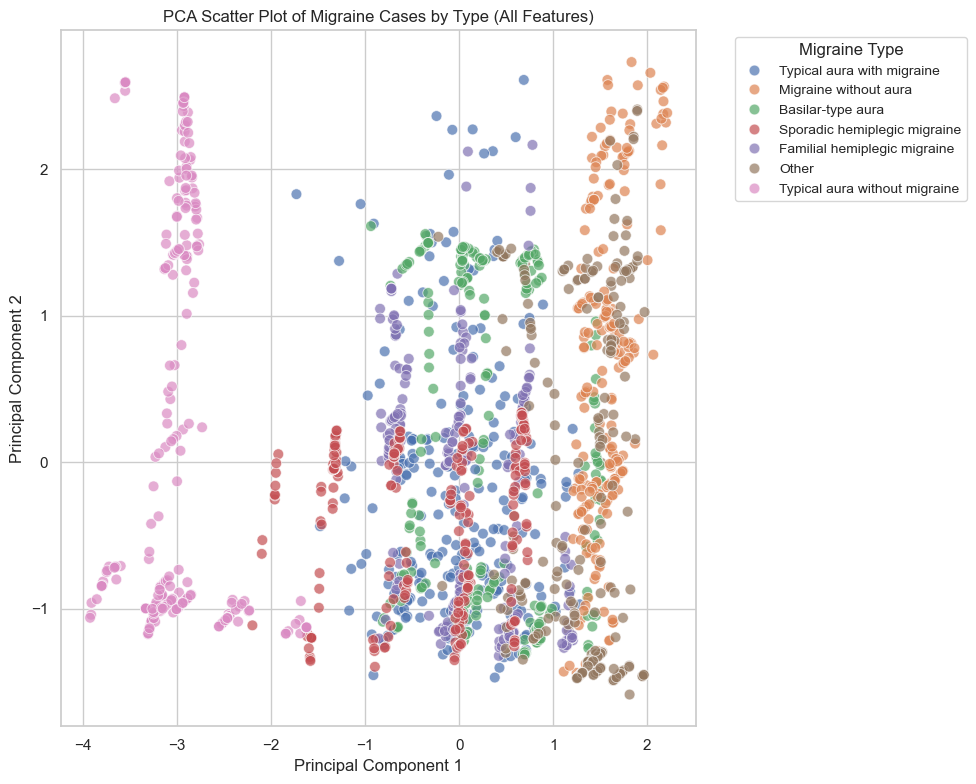

In [40]:
from sklearn.preprocessing import LabelEncoder

y_original = df['Type']  # Replace 'Type' with the correct column name
le = LabelEncoder()
le.fit(y_original)

y_resampled_original = le.inverse_transform(y_resampled)
y_resampled = le.fit_transform(y_resampled_original)  # use the original label array here
# Convert to DataFrame for plotting
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Type'] = le.inverse_transform(y_resampled)  # Decode label back to original type

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Type', palette='deep', s=60, alpha=0.7)

plt.title("PCA Scatter Plot of Migraine Cases by Type (All Features)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Legend outside
plt.legend(title="Migraine Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

Principal component 1 shows which migrane type have the largest source of variance
Principal component 2 shows the largest varance orthogonal (perpindicular to if you think of vectors or just think of a variance that moves the data in a completley diffrent way than the largest variance) from principal componet 1

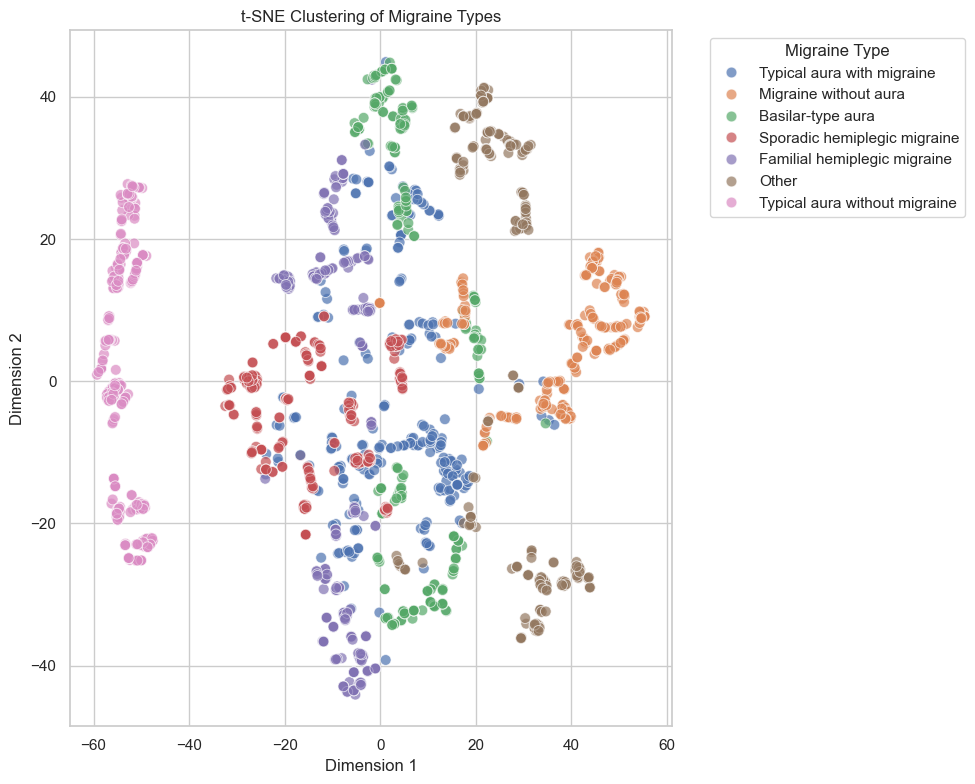

In [41]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_resampled) #this TSNE will contain all encoded and sacled features

tsne_df = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
tsne_df['Type'] = le.inverse_transform(y_resampled)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Type', palette='deep', s=60, alpha=0.7)

plt.title("t-SNE Clustering of Migraine Types")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Migraine Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


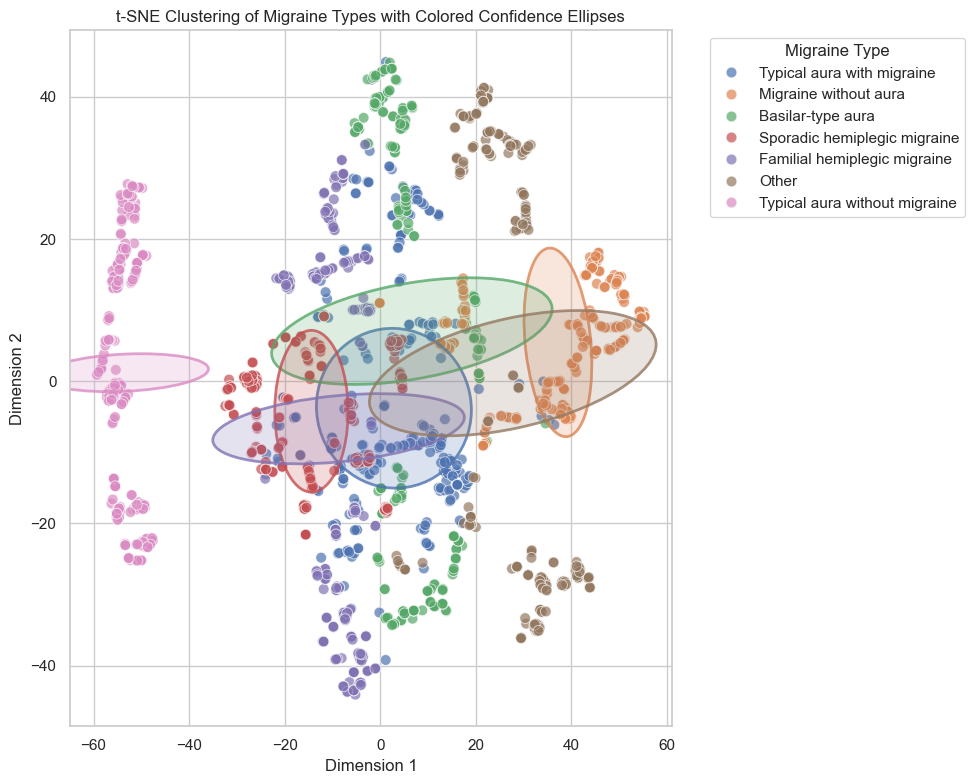

In [42]:

from matplotlib.patches import Ellipse
from matplotlib.colors import to_rgba

# t-SNE DataFrame setup
tsne_df = pd.DataFrame(X_tsne, columns=['Dim1', 'Dim2'])
tsne_df['Type'] = le.inverse_transform(y_resampled)

# Create color palette and map type to color
palette = sns.color_palette('deep', n_colors=tsne_df['Type'].nunique())
type_colors = dict(zip(tsne_df['Type'].unique(), palette))

# Helper to draw colored ellipse per migraine type
def draw_ellipse(x, y, ax, color):
    if len(x) < 2:
        return
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        edgecolor=to_rgba(color, 0.8),
        facecolor=to_rgba(color, 0.2),
        lw=2
    )
    ax.add_patch(ellipse)

# Plot with ellipses
plt.figure(figsize=(10, 8))
ax = plt.gca()

# Base scatter plot
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Type', palette=type_colors, s=60, alpha=0.7, ax=ax)

# Draw matching ellipses for each migraine type
for migraine_type, color in type_colors.items():
    subset = tsne_df[tsne_df['Type'] == migraine_type]
    draw_ellipse(subset['Dim1'].values, subset['Dim2'].values, ax, color)

plt.title("t-SNE Clustering of Migraine Types with Colored Confidence Ellipses")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Migraine Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

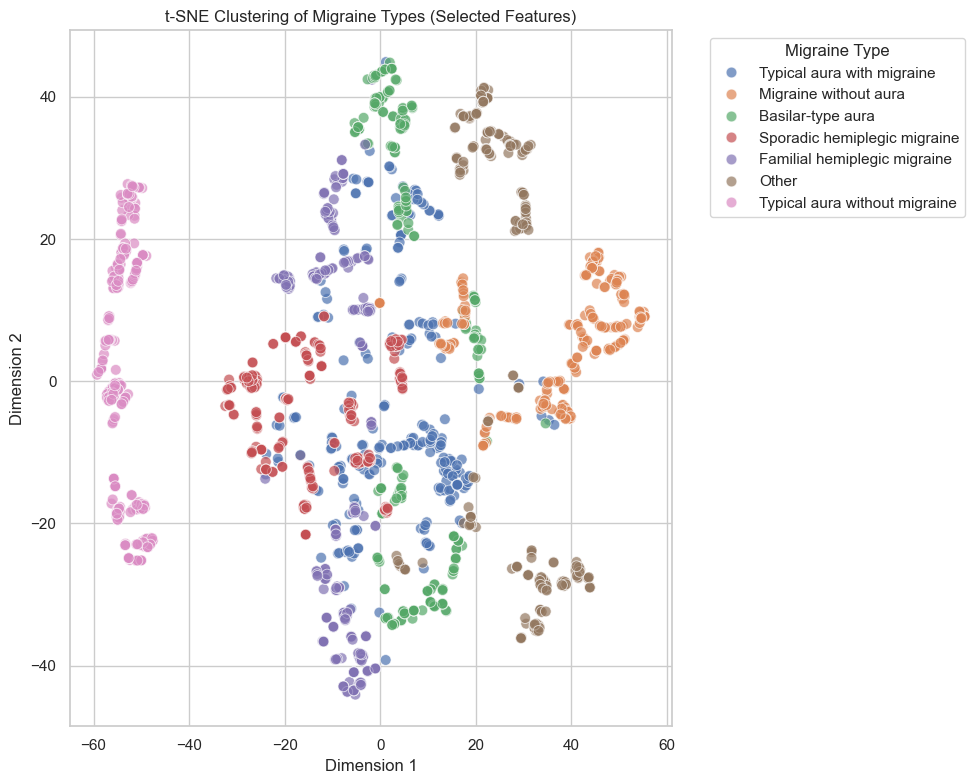

In [43]:

# Apply t-SNE to selected features
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_selected = tsne.fit_transform(X_selected)

# Format for plotting
tsne_selected_df = pd.DataFrame(X_tsne_selected, columns=['Dim1', 'Dim2'])
tsne_selected_df['Type'] = le.inverse_transform(y_resampled)

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='Dim1', y='Dim2', hue='Type', palette='deep', s=60, alpha=0.7)

plt.title("t-SNE Clustering of Migraine Types (Selected Features)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Migraine Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Dimension 1 and 2 show a visual map of simularity between cases. The closer points are together the more similar sympotms, intensity and frequency they have.

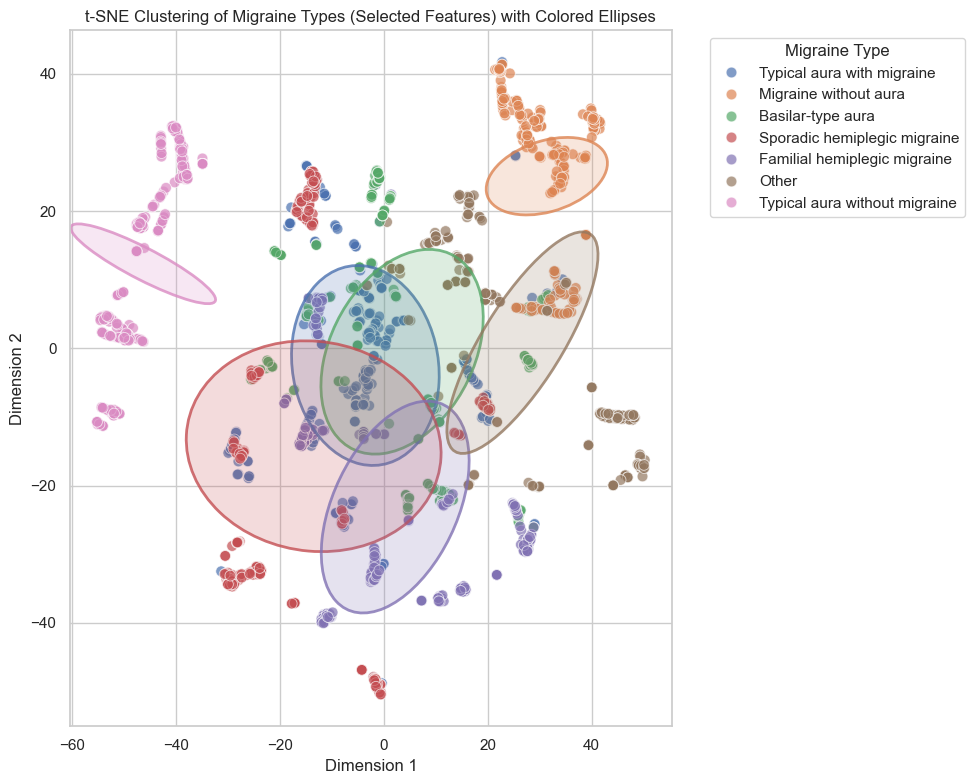

In [44]:

# Apply t-SNE to selected features
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_selected = tsne.fit_transform(X_selected)

# Setup DataFrame
tsne_selected_df = pd.DataFrame(X_tsne_selected, columns=['Dim1', 'Dim2'])
tsne_selected_df['Type'] = le.inverse_transform(y_resampled)

# Create color palette mapping
palette = sns.color_palette('deep', n_colors=tsne_selected_df['Type'].nunique())
type_colors = dict(zip(tsne_selected_df['Type'].unique(), palette))

# Draw color-coded ellipse per type
def draw_ellipse(x, y, ax, color):
    if len(x) < 2:
        return
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(*vecs[:, 1][::-1]))
    width, height = 2 * np.sqrt(vals)
    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        edgecolor=to_rgba(color, 0.8),
        facecolor=to_rgba(color, 0.2),
        lw=2
    )
    ax.add_patch(ellipse)

# Plot
plt.figure(figsize=(10, 8))
ax = plt.gca()
sns.scatterplot(data=tsne_selected_df, x='Dim1', y='Dim2', hue='Type', palette=type_colors, s=60, alpha=0.7, ax=ax)

# Add ellipses using matching colors
for migraine_type, color in type_colors.items():
    subset = tsne_selected_df[tsne_selected_df['Type'] == migraine_type]
    draw_ellipse(subset['Dim1'].values, subset['Dim2'].values, ax, color)

plt.title("t-SNE Clustering of Migraine Types (Selected Features) with Colored Ellipses")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(title="Migraine Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Step 3 Model Building

In [45]:
from sklearn.model_selection import train_test_split

# Split selected features
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_resampled, test_size=0.2, random_state=42, 
                                                    stratify=y_resampled)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

# Evaluate
y_pred_logreg = logreg.predict(X_test)
print("📘 Logistic Regression Report:\n", classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))

📘 Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.84      0.73      0.78        49
           1       0.87      0.84      0.85        49
           2       0.91      1.00      0.95        49
           3       1.00      0.96      0.98        50
           4       0.73      0.86      0.79        50
           5       0.67      0.61      0.64        49
           6       1.00      1.00      1.00        50

    accuracy                           0.86       346
   macro avg       0.86      0.86      0.86       346
weighted avg       0.86      0.86      0.86       346

Confusion Matrix:
 [[36  4  2  0  3  4  0]
 [ 2 41  0  0  0  6  0]
 [ 0  0 49  0  0  0  0]
 [ 0  0  2 48  0  0  0]
 [ 2  0  0  0 43  5  0]
 [ 3  2  1  0 13 30  0]
 [ 0  0  0  0  0  0 50]]


In [47]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred_rf = rf.predict(X_test)
print("🌳 Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

🌳 Random Forest Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92        49
           1       0.98      0.96      0.97        49
           2       0.96      0.98      0.97        49
           3       1.00      1.00      1.00        50
           4       0.92      0.90      0.91        50
           5       0.86      0.88      0.87        49
           6       1.00      1.00      1.00        50

    accuracy                           0.95       346
   macro avg       0.95      0.95      0.95       346
weighted avg       0.95      0.95      0.95       346

Confusion Matrix:
 [[45  1  1  0  0  2  0]
 [ 1 47  0  0  0  1  0]
 [ 1  0 48  0  0  0  0]
 [ 0  0  0 50  0  0  0]
 [ 1  0  0  0 45  4  0]
 [ 1  0  1  0  4 43  0]
 [ 0  0  0  0  0  0 50]]


In [48]:
logreg_report = classification_report(y_test, y_pred_logreg, output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)
logreg_conf_matrix = confusion_matrix(y_test, y_pred_logreg)
rf_conf_matrix = confusion_matrix(y_test, y_pred_rf)

In [49]:

import sys
print(sys.executable)


C:\ProgramData\anaconda3\python.exe


In [50]:
import site
site.getusersitepackages()


'C:\\Users\\rimsh\\AppData\\Roaming\\Python\\Python312\\site-packages'

In [51]:
sys.path.append(site.getusersitepackages())

In [52]:
!python -m pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [53]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
print("🚀 XGBoost Report:\n", classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

🚀 XGBoost Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94        49
           1       0.98      0.94      0.96        49
           2       0.96      0.98      0.97        49
           3       1.00      1.00      1.00        50
           4       0.90      0.92      0.91        50
           5       0.89      0.86      0.88        49
           6       1.00      1.00      1.00        50

    accuracy                           0.95       346
   macro avg       0.95      0.95      0.95       346
weighted avg       0.95      0.95      0.95       346

Confusion Matrix:
 [[47  1  1  0  0  0  0]
 [ 1 46  0  0  0  2  0]
 [ 1  0 48  0  0  0  0]
 [ 0  0  0 50  0  0  0]
 [ 1  0  0  0 46  3  0]
 [ 1  0  1  0  5 42  0]
 [ 0  0  0  0  0  0 50]]


In [54]:

xgb_report = classification_report(y_test, y_pred_xgb, output_dict=True)
xgb_conf_matrix = confusion_matrix(y_test, y_pred_xgb)

In [55]:
!pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [56]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
print("💡 LightGBM Report:\n", classification_report(y_test, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 533
[LightGBM] [Info] Number of data points in the train set: 1383, number of used features: 10
[LightGBM] [Info] Start training from score -1.943743
[LightGBM] [Info] Start training from score -1.943743
[LightGBM] [Info] Start training from score -1.943743
[LightGBM] [Info] Start training from score -1.948807
[LightGBM] [Info] Start training from score -1.948807
[LightGBM] [Info] Start training from score -1.943743
[LightGBM] [Info] Start training from score -1.948807
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

In [57]:
lgb_report = classification_report(y_test, y_pred_lgb, output_dict=True)
lgb_conf_matrix = confusion_matrix(y_test, y_pred_lgb)

In [58]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# One-hot encode target labels
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Define simple feedforward network
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=20, batch_size=32, verbose=1)

# Predict
y_pred_nn = model.predict(X_test)
y_pred_nn_labels = np.argmax(y_pred_nn, axis=1)

print("🧠 Neural Network Report:\n", classification_report(y_test, y_pred_nn_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn_labels))

Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2761 - loss: 1.8720
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6073 - loss: 1.3646
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7299 - loss: 1.0147
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.7613
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8128 - loss: 0.5929
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8361 - loss: 0.5129
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8200 - loss: 0.4821
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8271 - loss: 0.4603
Epoch 9/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8494 - loss: 0.4315
Epoch 10/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8498 - loss: 0.3990
Epoch 11/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8422 - loss: 0.4174
Epoch 12/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8561 - lo

In [60]:
nn_report = classification_report(y_test, y_pred_nn_labels, output_dict=True)
nn_conf_matrix = confusion_matrix(y_test, y_pred_nn_labels)

In [61]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='f1_weighted', verbose=1)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.9405359525647254


In [62]:
!pip install optuna

Defaulting to user installation because normal site-packages is not writeable


In [63]:
import optuna
from sklearn.model_selection import cross_val_score


def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='mlogloss')
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='f1_weighted').mean()
    return score

# Create study and set limits
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, timeout=200)  #Limit to 3 minutes

# Output best parameters
print("✅ Best Parameters Found:")
for key, val in study.best_params.items():
    print(f"  {key}: {val}")

[I 2025-07-19 18:08:27,396] A new study created in memory with name: no-name-56ec3702-cd19-490f-9738-da5e1f094214
[I 2025-07-19 18:08:29,168] Trial 0 finished with value: 0.9370649778494052 and parameters: {'n_estimators': 194, 'max_depth': 14, 'learning_rate': 0.29453665830166254, 'subsample': 0.7795236724656914, 'colsample_bytree': 0.6961103708160212}. Best is trial 0 with value: 0.9370649778494052.
[I 2025-07-19 18:08:30,616] Trial 1 finished with value: 0.9397001849376587 and parameters: {'n_estimators': 145, 'max_depth': 15, 'learning_rate': 0.15519240194834424, 'subsample': 0.7592887404855072, 'colsample_bytree': 0.949020803548795}. Best is trial 1 with value: 0.9397001849376587.
[I 2025-07-19 18:08:33,184] Trial 2 finished with value: 0.9426603231369447 and parameters: {'n_estimators': 178, 'max_depth': 12, 'learning_rate': 0.0365416919530336, 'subsample': 0.8592758873460866, 'colsample_bytree': 0.6698756494472433}. Best is trial 2 with value: 0.9426603231369447.
[I 2025-07-19 1

✅ Best Parameters Found:
  n_estimators: 102
  max_depth: 8
  learning_rate: 0.09463378841037373
  subsample: 0.9131327191217431
  colsample_bytree: 0.7431001288671447


In [64]:


from tensorflow.keras.optimizers import Adam, RMSprop




# One-hot encode the target
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

def objective(trial):
    # Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 1, 3)
    units = trial.suggest_int('units', 32, 128)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    # Build model
    model = Sequential()
    model.add(Dense(units, activation=activation, input_dim=X_train.shape[1]))
    for _ in range(n_layers - 1):
        model.add(Dense(units, activation=activation))
    model.add(Dense(num_classes, activation='softmax'))

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    model.fit(X_train, y_train_cat, epochs=15, batch_size=32, verbose=0)

    # Evaluate
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    score = f1_score(y_test, y_pred, average='weighted')
    return score

In [65]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, timeout=200)  #Limit to 3 minutes

print("✨ Best Parameters Found:", study.best_params)

[I 2025-07-19 18:08:56,726] A new study created in memory with name: no-name-ce525bdd-6293-44b3-99fc-1438a66d494c


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


[I 2025-07-19 18:09:00,124] Trial 0 finished with value: 0.8041292041192981 and parameters: {'n_layers': 1, 'units': 46, 'activation': 'relu', 'optimizer': 'rmsprop', 'learning_rate': 0.00031331677362013736}. Best is trial 0 with value: 0.8041292041192981.


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


[I 2025-07-19 18:09:03,902] Trial 1 finished with value: 0.8808822845630322 and parameters: {'n_layers': 2, 'units': 116, 'activation': 'tanh', 'optimizer': 'rmsprop', 'learning_rate': 0.0023161399699050235}. Best is trial 1 with value: 0.8808822845630322.


...

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


[I 2025-07-19 18:09:48,443] Trial 13 finished with value: 0.9300500768206376 and parameters: {'n_layers': 2, 'units': 127, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.004665489686874309}. Best is trial 13 with value: 0.9300500768206376.


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


[I 2025-07-19 18:09:52,600] Trial 14 finished with value: 0.9097662136199652 and parameters: {'n_layers': 2, 'units': 86, 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.005035907076509754}. Best is trial 13 with value: 0.9300500768206376.


✨ Best Parameters Found: {'n_layers': 2, 'units': 127, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.004665489686874309}


In [66]:

def objective(trial):
    # Define the hyperparameter space
    C = trial.suggest_float("C", 1e-5, 10.0, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    solver = trial.suggest_categorical("solver", ["liblinear", "saga"])

    # Validate solver and penalty compatibility
    if penalty == "l1" and solver not in ["liblinear", "saga"]:
        raise optuna.exceptions.TrialPruned()
    if penalty == "l2" and solver == "saga":
        raise optuna.exceptions.TrialPruned()

    # Build and evaluate the model
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_weighted').mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, timeout=200, n_trials=15)



print("Best Parameters:", study.best_params)

[I 2025-07-19 18:09:52,630] A new study created in memory with name: no-name-46ea7d73-99c8-463b-8ec2-17e237bc9b70
[I 2025-07-19 18:09:53,086] Trial 0 finished with value: 0.8166604546221805 and parameters: {'C': 0.0879452830362338, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 0 with value: 0.8166604546221805.
[I 2025-07-19 18:09:53,164] Trial 1 finished with value: 0.8116076206026268 and parameters: {'C': 0.20243011268622232, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 0 with value: 0.8166604546221805.
[I 2025-07-19 18:09:53,166] Trial 2 pruned. 
[I 2025-07-19 18:09:53,212] Trial 3 finished with value: 0.4810978143010417 and parameters: {'C': 0.008648727050307338, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 0.8166604546221805.
[I 2025-07-19 18:09:53,222] Trial 4 pruned. 
[I 2025-07-19 18:09:56,835] Trial 5 finished with value: 0.8473442013654802 and parameters: {'C': 9.121473967981009, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 5 with val

Best Parameters: {'C': 0.9641623659234094, 'penalty': 'l1', 'solver': 'saga'}


# Step 4 Model Evaluation

In [67]:

print("Evaluation of the Logistic Regression")
accuracy = accuracy_score(y_test, y_pred_logreg)
f1 = f1_score(y_test, y_pred_logreg, average='weighted')  
conf_matrix = confusion_matrix(y_test, y_pred_logreg)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Evaluation of the Logistic Regression
Accuracy: 0.8583815028901735
F1 Score: 0.8570204648634202
Confusion Matrix:
 [[36  4  2  0  3  4  0]
 [ 2 41  0  0  0  6  0]
 [ 0  0 49  0  0  0  0]
 [ 0  0  2 48  0  0  0]
 [ 2  0  0  0 43  5  0]
 [ 3  2  1  0 13 30  0]
 [ 0  0  0  0  0  0 50]]


In [68]:
print("Evaluation of the Random Forest")
accuracy = accuracy_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf, average='weighted')  
conf_matrix = confusion_matrix(y_test, y_pred_rf)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Evaluation of the Random Forest
Accuracy: 0.9479768786127167
F1 Score: 0.9480343630573056
Confusion Matrix:
 [[45  1  1  0  0  2  0]
 [ 1 47  0  0  0  1  0]
 [ 1  0 48  0  0  0  0]
 [ 0  0  0 50  0  0  0]
 [ 1  0  0  0 45  4  0]
 [ 1  0  1  0  4 43  0]
 [ 0  0  0  0  0  0 50]]


In [69]:
print("Evaluation of the XGBoost")
accuracy = accuracy_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb, average='weighted')  
conf_matrix = confusion_matrix(y_test, y_pred_xgb)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Evaluation of the XGBoost
Accuracy: 0.9508670520231214
F1 Score: 0.9507313274680069
Confusion Matrix:
 [[47  1  1  0  0  0  0]
 [ 1 46  0  0  0  2  0]
 [ 1  0 48  0  0  0  0]
 [ 0  0  0 50  0  0  0]
 [ 1  0  0  0 46  3  0]
 [ 1  0  1  0  5 42  0]
 [ 0  0  0  0  0  0 50]]


In [70]:
print("Evaluation of the LightGBM")
accuracy = accuracy_score(y_test, y_pred_lgb)
f1 = f1_score(y_test, y_pred_lgb, average='weighted')  
conf_matrix = confusion_matrix(y_test, y_pred_lgb)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Evaluation of the LightGBM
Accuracy: 0.9624277456647399
F1 Score: 0.9624268427677044
Confusion Matrix:
 [[46  1  1  0  0  1  0]
 [ 1 47  0  0  0  1  0]
 [ 1  0 48  0  0  0  0]
 [ 0  0  0 50  0  0  0]
 [ 1  0  0  0 47  2  0]
 [ 0  0  1  0  3 45  0]
 [ 0  0  0  0  0  0 50]]


In [71]:
print("Evaluation of the Nerual Network")
accuracy = accuracy_score(y_test, y_pred_nn_labels)
f1 = f1_score(y_test, y_pred_nn_labels, average='weighted')  
conf_matrix = confusion_matrix(y_test, y_pred_nn_labels)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Evaluation of the Nerual Network
Accuracy: 0.8930635838150289
F1 Score: 0.8904068364969903
Confusion Matrix:
 [[39  4  2  0  2  2  0]
 [ 7 40  0  0  0  2  0]
 [ 0  0 49  0  0  0  0]
 [ 0  0  2 48  0  0  0]
 [ 0  0  0  0 50  0  0]
 [ 1  2  2  0 11 33  0]
 [ 0  0  0  0  0  0 50]]


All models have an accuarcy between 85% and 97% meaning the testing has shown these models are correctly predicting the type of migrane the vast majority of the time. The F1 scores also fall into this range which shows that it is recalling relevent information consistently and is handling both false positive and false negitives well.

In [72]:


models = {
    "LogReg": logreg,
    "Random Forest": rf,
    "XGBoost": xgb_model,
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted')
    print(f"{name} Mean F1: {scores.mean():.4f}, Std: {scores.std():.4f}")

LogReg Mean F1: 0.8476, Std: 0.0635
Random Forest Mean F1: 0.8725, Std: 0.0264
XGBoost Mean F1: 0.8434, Std: 0.0218


In [73]:
from sklearn.model_selection import StratifiedKFold

import tensorflow.keras.backend as K

# Make sure y is in integer format — not one-hot
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

for train_idx, val_idx in skf.split(X, y):
    # Re-split and re-one-hot encode train targets
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]

    y_train_fold_cat = to_categorical(y.iloc[train_idx], num_classes)
    # Rebuild the tuned model (based on your existing settings)
    model = Sequential([
        Dense(64, activation='relu', input_dim=X.shape[1]),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    # Train silently
    model.fit(X_train_fold, y_train_fold_cat, epochs=20, batch_size=32, verbose=0)

    # Predict and evaluate
    y_pred_probs = model.predict(X_val_fold)
    y_pred_fold = np.argmax(y_pred_probs, axis=1)
    f1 = f1_score(y[val_idx], y_pred_fold, average='weighted')
    f1_scores.append(f1)

    # Clean up session to free memory
    K.clear_session()

print("🧪 Neural Network Stratified CV F1 Scores:", np.round(f1_scores, 4))
print("Mean F1:", np.mean(f1_scores).round(4), "| Std Dev:", np.std(f1_scores).round(4))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/stepWARNING:tensorflow:6 out of the last 17 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000276750CECA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
🧪 Neural Network Stratified CV F1 Scores: [0.

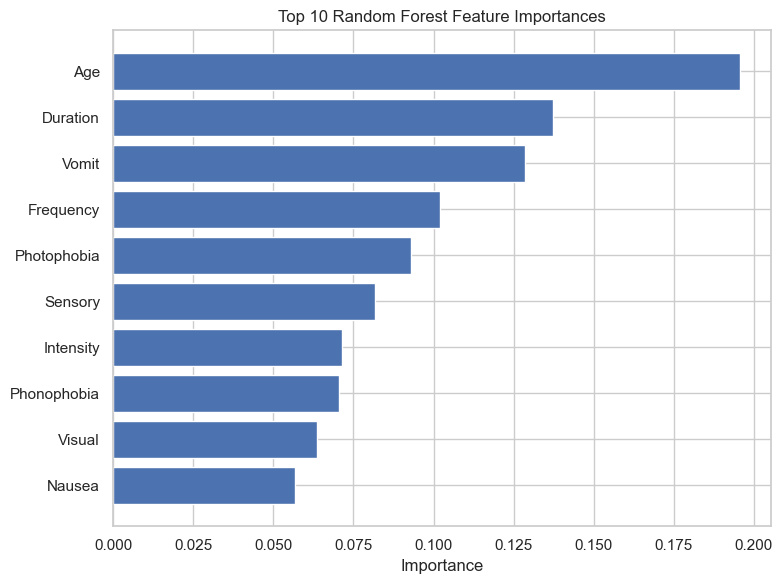

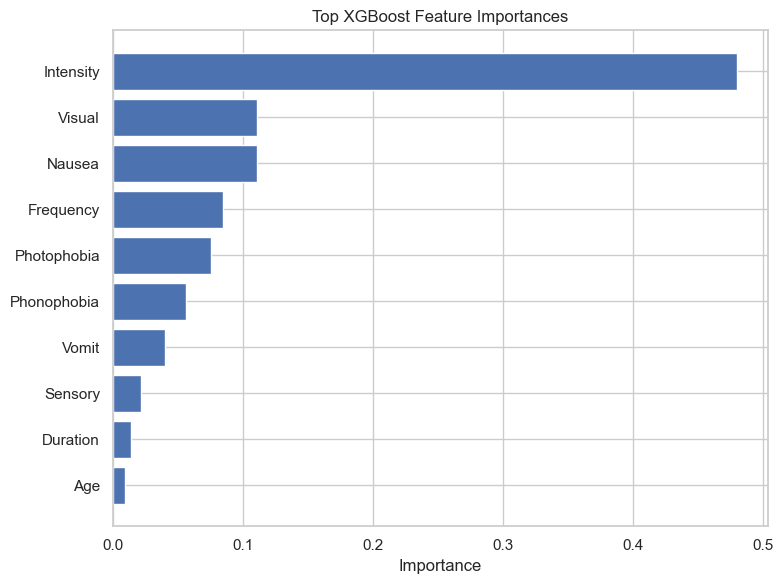

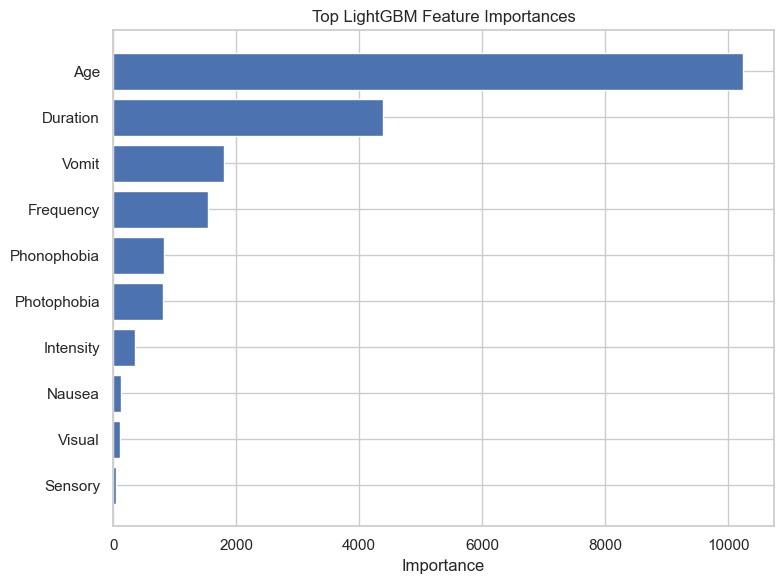

In [74]:

# For Random Forest
top_n = 10
feat_imp_rf = rf.feature_importances_  
indices = np.argsort(feat_imp_rf)[-top_n:]  # indices of top N features
top_features = X.columns[indices]
top_importances = feat_imp_rf[indices]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features, top_importances)
plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# For XGBoost
importances = xgb_model.feature_importances_
indices = importances.argsort()[::-1]

top_n = 10
top_features = [X.columns[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

plt.figure(figsize=(8, 6))
plt.barh(top_features[::-1], top_importances[::-1])  # Reverse for descending
plt.xlabel("Importance")
plt.title("Top XGBoost Feature Importances")
plt.tight_layout()
plt.show()

# For LightGBM

importances = lgb_model.feature_importances_
indices = importances.argsort()[::-1]

top_n = 10
top_features = [X.columns[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

plt.figure(figsize=(8, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Importance")
plt.title("Top LightGBM Feature Importances")
plt.tight_layout()
plt.show()


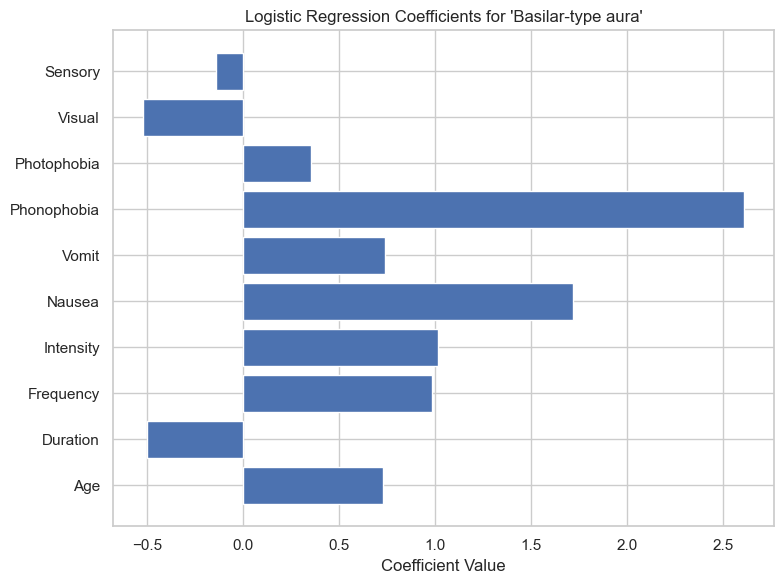

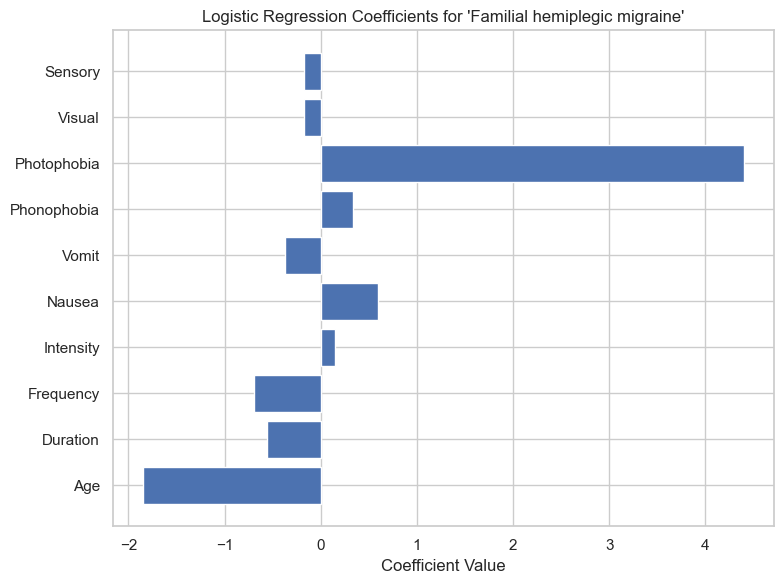

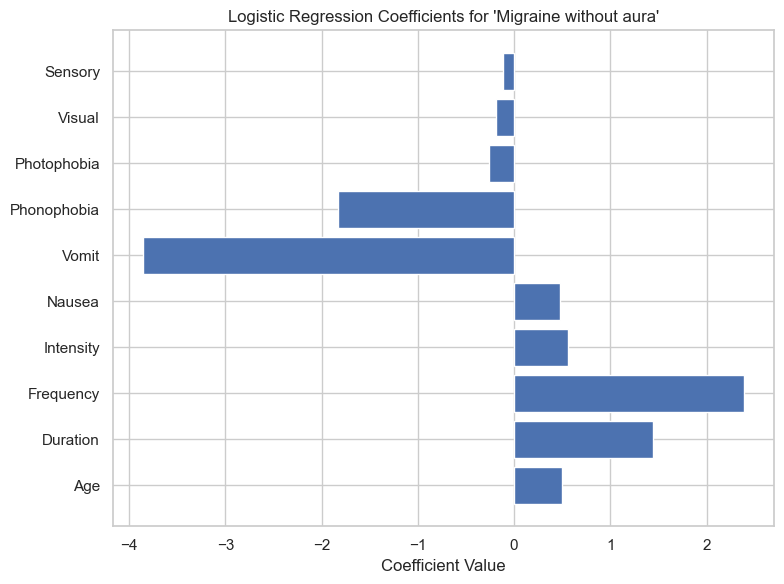

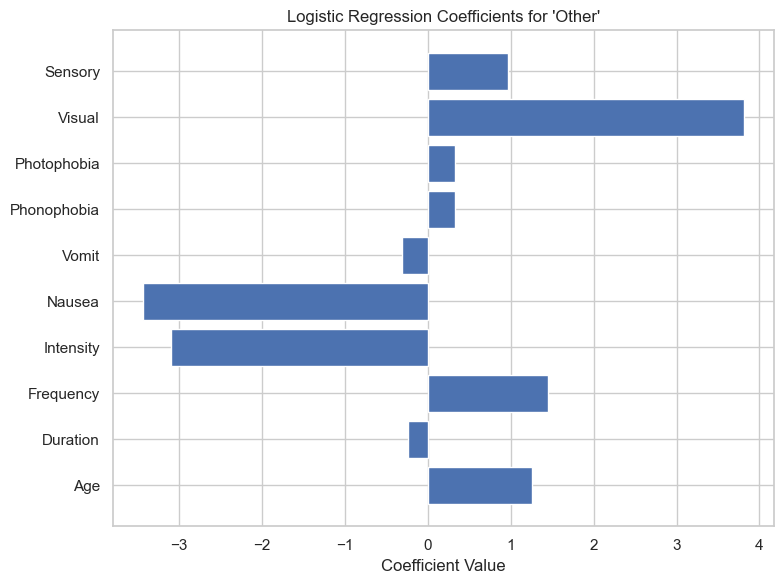

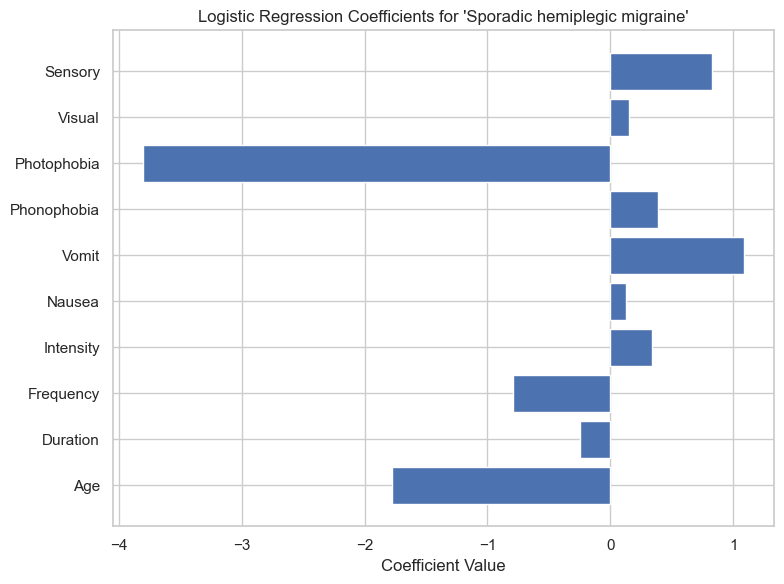

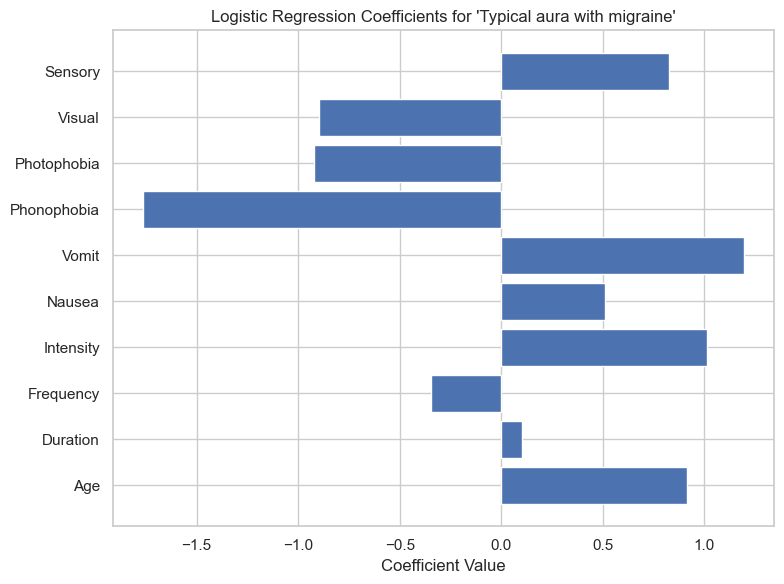

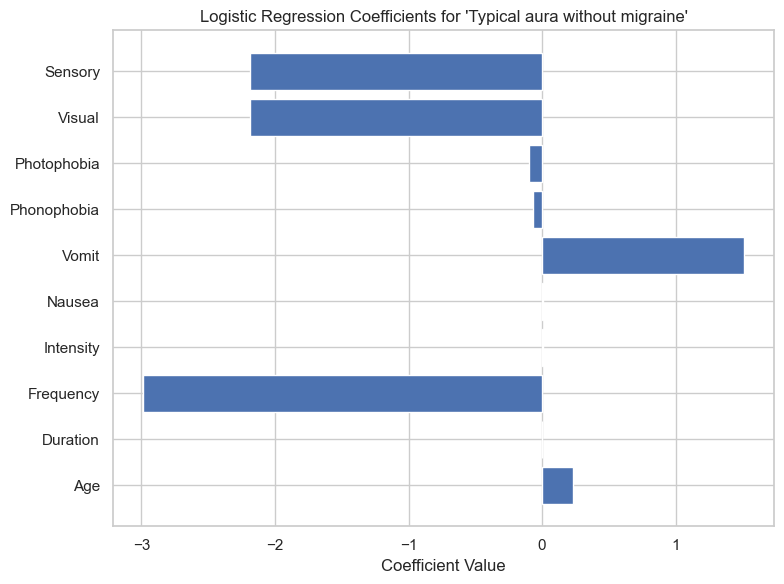

In [75]:
coefs = logreg.coef_
target_names = le.classes_  # Pulls decoded class names from fitted LabelEncoder

for i, class_coefs in enumerate(coefs):
    num_feats = len(class_coefs)
    feat_labels = X.columns[:num_feats]  # Adjust if features were preprocessed

    plt.figure(figsize=(8, 6))
    plt.barh(feat_labels, class_coefs)
    plt.title(f"Logistic Regression Coefficients for '{target_names[i]}'")
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.show()


11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


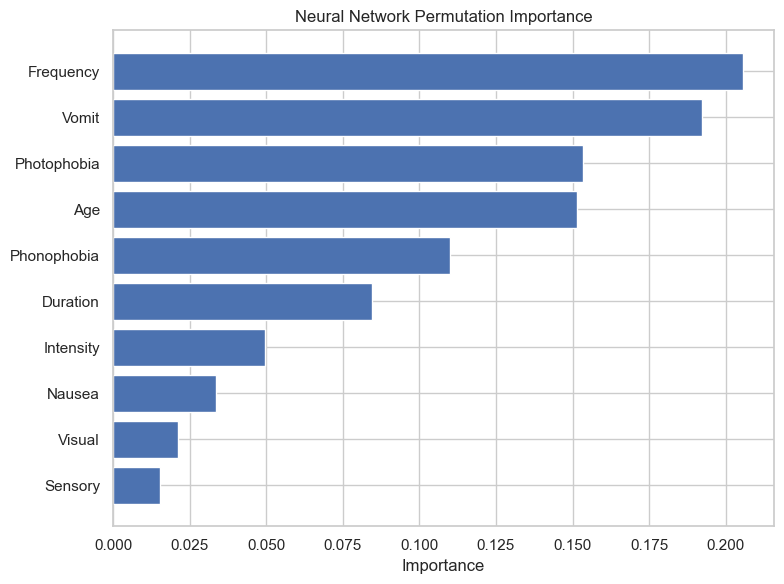

In [76]:
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier  THIS GOT DEPRECATED
from sklearn.inspection import permutation_importance

from sklearn.base import BaseEstimator


class KerasNNWrapper(BaseEstimator):
    def __init__(self, build_fn, epochs=20, batch_size=32, verbose=0):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model = None

    def fit(self, X, y):
        self.model = self.build_fn()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose)
        return self

    def predict(self, X):
        y_probs = self.model.predict(X)
        return np.argmax(y_probs, axis=1)

# Define your model factory function
# Define your model builder
def build_nn_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap it
nn_estimator = KerasNNWrapper(build_fn=build_nn_model, epochs=20, batch_size=32, verbose=0)
nn_estimator.fit(X_train, y_train_cat)

# Use permutation importance
from sklearn.inspection import permutation_importance
result = permutation_importance(
    estimator=nn_estimator,
    X=X_test,
    y=y_test,
    scoring='f1_weighted',
    n_repeats=10,
    random_state=42
)

# Plot
sorted_idx = np.argsort(result.importances_mean)
plt.figure(figsize=(8, 6))
plt.barh(np.array(X.columns)[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Neural Network Permutation Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Step 5  Model Saving and Deployment

In [77]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(logreg, 'logistic_regression_model.pkl')
joblib.dump(xgb_model, 'xgboost_model.pkl')
joblib.dump(lgb_model, 'lightgbm_model.pkl')
#model.save('neural_net_model.keras') 

joblib.dump(le, 'label_encoder.pkl')


#joblib.dump(X_df.columns.tolist(), 'training_feature_names.pkl')



['label_encoder.pkl']

In [78]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'Neural Network': KerasNNWrapper(build_fn=build_nn_model, epochs=20, batch_size=32, verbose=0)
}

result= {}

for name, model in models.items():
    if name == 'Neural Network':
        # Use one-hot encoded labels for training
        model.fit(X_train, y_train_cat)  # y_train_cat is the one-hot version
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Always compare predictions to integer labels
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    result[name] = {'model': model, 'accuracy': acc, 'F1-Score': f1}
    
    print(f'\n{name} Performance:')
    print('Accuracy:', acc)
    print('F1-Score:', f1)
    print(classification_report(y_test, y_pred))

best_model_name = max(result, key=lambda x: result[x]['F1-Score'])
best_model = result[best_model_name]['model']




Random Forest Performance:
Accuracy: 0.9479768786127167
F1-Score: 0.9480343630573056
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        49
           1       0.98      0.96      0.97        49
           2       0.96      0.98      0.97        49
           3       1.00      1.00      1.00        50
           4       0.92      0.90      0.91        50
           5       0.86      0.88      0.87        49
           6       1.00      1.00      1.00        50

    accuracy                           0.95       346
   macro avg       0.95      0.95      0.95       346
weighted avg       0.95      0.95      0.95       346


Logistic Regression Performance:
Accuracy: 0.8583815028901735
F1-Score: 0.8570204648634202
              precision    recall  f1-score   support

           0       0.84      0.73      0.78        49
           1       0.87      0.84      0.85        49
           2       0.91      1.00      0.95        49
        

In [79]:
print("best model is: ", best_model_name)

best model is:  LightGBM


In [80]:

# Load your training features
training_features = joblib.load('training_feature_names.pkl')

# Simulate incoming symptoms
symptom_list = ['nausea', 'visual', 'unilateral']  # example from user input

# Load encoder and weights
mlb = joblib.load('mlb.pkl')
symptoms_weights = joblib.load('symptoms_weights.pkl')

# Encode and weight
symptoms_vec = mlb.transform([symptom_list])
symptoms_df = pd.DataFrame(symptoms_vec, columns=mlb.classes_)
for col in symptoms_df.columns:
    symptoms_df[col] *= symptoms_weights.get(col, 1)

# Add numeric features
symptoms_df['age'] = 32
symptoms_df['duration'] = 6

# ✅ Reindex to align with training schema
aligned_input = symptoms_df.reindex(columns=training_features, fill_value=0)

In [84]:


def predict_migraine_type(age, duration, location, nausea, visual, motor):
    # Map input to symptom-style list
    symptom_list = []

    if location.lower() == 'unilateral':
        symptom_list.append('unilateral')
    elif location.lower() == 'bilateral':
        symptom_list.append('bilateral')

    if nausea.lower() == 'yes': symptom_list.append('nausea')
    if visual.lower() == 'yes': symptom_list.append('visual')
    if motor.lower() == 'yes': symptom_list.append('motor')

    # Encode symptoms with MLB
    symptoms_vec = mlb.transform([symptom_list])
    symptoms_df = pd.DataFrame(symptoms_vec, columns=mlb.classes_)

    # Apply optional weights
    for col in symptoms_df.columns:
        symptoms_df[col] *= symptoms_weights.get(col, 1)

    # Add numeric features
    symptoms_df['age'] = age
    symptoms_df['duration'] = duration

    # 🔁 Align columns to match training
    training_features = joblib.load("training_feature_names.pkl")
    symptoms_df = symptoms_df.reindex(columns=training_features, fill_value=0)
    # Ensure all expected features are present and aligned
    training_features = joblib.load('training_feature_names.pkl')
    symptoms_df = symptoms_df.reindex(columns=training_features, fill_value=0)
    # Predict
    prediction = model.predict(symptoms_df)[0]
    confidence = round(np.max(model.predict_proba(symptoms_df)) * 100, 1)

    print(f"Predicted Migraine Type: {prediction}")
    print(f"Confidence: {confidence}%")

    return {
        "Migraine Type": str(prediction).title(),
        "Confidence": f"{confidence}%"
    }



# Load model and preprocessing artifacts
model = joblib.load("best_model.pkl")
mlb = joblib.load("mlb.pkl")
symptoms_weights = joblib.load("symptoms_weights.pkl")
training_features = joblib.load("training_feature_names.pkl")

# Only use known and collected symptoms
controlled_symptoms = ['unilateral', 'bilateral', 'nausea', 'visual', 'motor']

# Fit MLB using full set at once
mlb = MultiLabelBinarizer(classes=controlled_symptoms)
mlb.fit([controlled_symptoms])  # Fit on the known values

# Save encoder and feature list
joblib.dump(mlb, 'mlb.pkl')
training_features = controlled_symptoms + ['age', 'duration']
joblib.dump(training_features, 'training_feature_names.pkl')
symptom_data = [
    ['unilateral', 'visual', 'nausea'],
    ['bilateral', 'motor'],
    ['visual'],
    ['nausea', 'motor', 'unilateral']]
symptom_data += [
    ['unilateral', 'motor'],                     # hemiplegic
    ['bilateral', 'nausea', 'visual'],           
    ['unilateral', 'visual', 'motor', 'nausea']  # Complex aura pattern
]


mlb = MultiLabelBinarizer(classes=controlled_symptoms)
mlb.fit([controlled_symptoms])
X_symptoms = mlb.transform(symptom_data)

X_full = pd.DataFrame(X_symptoms, columns=mlb.classes_)
X_full['age'] = df['Age']
X_full['duration'] = df['Duration']

joblib.dump(list(X_full.columns), 'training_feature_names.pkl')
# Example target labels for 4 samples

y = [
    "Typical aura with migraine",
    "Migraine without aura",
    "Basilar-type aura",
    "Sporadic hemiplegic migraine",
    "Familial hemiplegic migraine",
    "Other",
    "Typical aura without migraine"
]

model.fit(X_full, y)
joblib.dump(model, 'best_model.pkl')

# Load model and encoders
model = joblib.load("best_model.pkl")
mlb = joblib.load("mlb.pkl")
symptoms_weights = joblib.load("symptoms_weights.pkl")
training_features = joblib.load("training_feature_names.pkl")

def predict_migraine_type_cli():
    age = int(input("Patient Age: "))
    duration = float(input("Duration of episode (in hours): "))
    location = input("Location of pain (Unilateral/Bilateral): ").strip()
    nausea = input("Nausea? (Yes/No): ").strip()
    visual = input("Visual disturbances? (Yes/No): ").strip()
    motor = input("Motor symptoms? (Yes/No): ").strip()

    # Build symptom list
    symptom_list = []
    if location.lower() == 'unilateral': symptom_list.append('unilateral')
    elif location.lower() == 'bilateral': symptom_list.append('bilateral')
    if nausea.lower() == 'yes': symptom_list.append('nausea')
    if visual.lower() == 'yes': symptom_list.append('visual')
    if motor.lower() == 'yes': symptom_list.append('motor')

    # Encode symptoms
    symptoms_vec = mlb.transform([symptom_list])
    symptoms_df = pd.DataFrame(symptoms_vec, columns=mlb.classes_)

    # Apply weights
    for col in symptoms_df.columns:
        symptoms_df[col] *= symptoms_weights.get(col, 1)

    # Add numeric features
    symptoms_df['age'] = age
    symptoms_df['duration'] = duration

    # Align to training feature order
    symptoms_df = symptoms_df.reindex(columns=training_features, fill_value=0)

    # Predict
    prediction = model.predict(symptoms_df)[0]

    print(f"\n Predicted Migraine Type: {str(prediction).title()}")

# Run it
predict_migraine_type_cli()

Patient Age:  32
Duration of episode (in hours):  6
Location of pain (Unilateral/Bilateral):  Bilateral
Nausea? (Yes/No):  No
Visual disturbances? (Yes/No):  No
Motor symptoms? (Yes/No):  No



 Predicted Migraine Type: Migraine Without Aura


In [82]:
"""
import streamlit as st


# Load trained model
model = joblib.load('random_forest_model.pkl')  # Replace with your best model
#label_encoder = joblib.load('saved_models/label_encoder.joblib')  

# Streamlit Interface
st.title("Migraine Type Predictor 🧠")
st.write("Enter patient symptoms to predict migraine subtype")

# Inputs
age = st.slider("Age", 10, 100, value=32)
duration = st.slider("Duration (hours)", 1, 72, value=6)
location = st.selectbox("Location", ["Unilateral", "Bilateral"])
nausea = st.selectbox("Nausea", ["Yes", "No"])
visual = st.selectbox("Visual Symptoms", ["Yes", "No"])
motor = st.selectbox("Motor Symptoms", ["Yes", "No"])

# Convert categorical to numeric if needed
location_map = {"Unilateral": 1, "Bilateral": 0}
binary_map = {"Yes": 1, "No": 0}

features = np.array([[
    age,
    duration,
    location_map[location],
    binary_map[nausea],
    binary_map[visual],
    binary_map[motor]
]])

# Predict
if st.button("Predict"):
    pred_probs = model.predict_proba(features)
    pred_label = model.predict(features)[0]
    confidence = np.max(pred_probs) * 100
    decoded_label = label_encoder.inverse_transform([pred_label])[0]

    st.success(f"🔍 Predicted: **{decoded_label}**")
    st.info(f"Confidence: **{confidence:.1f}%**")
    """

'\nimport streamlit as st\n\n\n# Load trained model\nmodel = joblib.load(\'random_forest_model.pkl\')  # Replace with your best model\n#label_encoder = joblib.load(\'saved_models/label_encoder.joblib\')  \n\n# Streamlit Interface\nst.title("Migraine Type Predictor 🧠")\nst.write("Enter patient symptoms to predict migraine subtype")\n\n# Inputs\nage = st.slider("Age", 10, 100, value=32)\nduration = st.slider("Duration (hours)", 1, 72, value=6)\nlocation = st.selectbox("Location", ["Unilateral", "Bilateral"])\nnausea = st.selectbox("Nausea", ["Yes", "No"])\nvisual = st.selectbox("Visual Symptoms", ["Yes", "No"])\nmotor = st.selectbox("Motor Symptoms", ["Yes", "No"])\n\n# Convert categorical to numeric if needed\nlocation_map = {"Unilateral": 1, "Bilateral": 0}\nbinary_map = {"Yes": 1, "No": 0}\n\nfeatures = np.array([[\n    age,\n    duration,\n    location_map[location],\n    binary_map[nausea],\n    binary_map[visual],\n    binary_map[motor]\n]])\n\n# Predict\nif st.button("Predict"):\n

In [83]:
#!streamlit run C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py